# Análisis conductual — Mixed Models con pymer4
Versión pymer4 (frecuentista, lme4 de R) en lugar de BinomialBayesMixedGLM

In [ ]:
from pymer4.models import lmer, glmer
import pandas as pd
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import norm
import warnings

sns.set(font_scale=1.3, style="ticks")
plt.rcParams["figure.dpi"] = 100
print("Librerías OK ✓")

Librerías OK ✓


In [2]:
# ── Celda 2: Cargar datos ───────────────────────────────────────────────────
data_path = "/Users/martu/Documents/TFG_MARTINA/dataset/CJ_EEG.csv"
all_df = pd.read_csv(data_path)
print(f"Dataset cargado: {all_df.shape[0]} filas, {all_df.shape[1]} columnas")
all_df.head(3)

Dataset cargado: 6600 filas, 36 columnas


,exp_ID,npar,subj,nblock,ntrial,nrep,cond-1,trial_type,rDV,deci-3,...,d6,o1,o2,o3,o4,o5,o6,metad,metad_3%,metad_97%
0,CJ_EEG,1,s01,0,0,0,0,repeat,-0.203974,0,...,-0.944496,2.697,0.715,1.903,1.576,1.214,1.549,0.086,-0.345,0.51
1,CJ_EEG,1,s01,0,0,1,0,repeat,-0.203974,0,...,-0.944496,2.697,0.715,1.903,1.576,1.214,1.549,0.086,-0.345,0.51
2,CJ_EEG,1,s01,0,0,2,0,repeat,-0.203974,0,...,-0.944496,2.697,0.715,1.903,1.576,1.214,1.549,0.086,-0.345,0.51


In [3]:
# ── Celda 3: Preprocesamiento ───────────────────────────────────────────────
df = all_df.copy()

df["cond"]    = df["cond"].replace({-1: 0})
df["correct"] = df["correct"].replace({-1: 0})
df["switch"]  = (df["deci"] != df["deci-1"]).astype(int)

median_confi   = df["confi"].median()
df["conf_lvl"] = np.where(df["confi"] >= median_confi, "H", "L")

df = df.sort_values(["subj", "nblock", "ntrial", "nrep"]).reset_index(drop=True)
df["confi-1"]   = df.groupby(["subj", "nblock", "ntrial"])["confi"].shift(1)
df["correct-1"] = df["corr-1"]

df["nrep_f"]    = df["nrep"].astype(str)
df["is_repeat"] = (df["trial_type"] == "repeat").astype(int)
df["deci1_c"]   = df["deci-1"] - 0.5
df["rDV_z"]     = df.groupby("subj")["rDV"].transform(
    lambda x: (x - x.mean()) / x.std())
df["metad_z"]   = (df["metad"] - df["metad"].mean()) / df["metad"].std()

print(f"cond      → {sorted(df['cond'].unique())}")
print(f"correct   → {sorted(df['correct'].unique())}")
print(f"switch    → {sorted(df['switch'].unique())}")
print(f"is_repeat → {sorted(df['is_repeat'].unique())}")
print(f"\nNaN confi-1  : {df['confi-1'].isna().sum()}")
print(f"NaN correct-1: {df['correct-1'].isna().sum()}")
print(f"\nTotal filas  : {len(df)}")
print(f"Participantes: {df['subj'].nunique()}")

cond      → [np.int64(0), np.int64(1)]
correct   → [np.int64(0), np.int64(1)]
switch    → [np.int64(0), np.int64(1)]
is_repeat → [np.int64(0), np.int64(1)]

NaN confi-1  : 2200
NaN correct-1: 0

Total filas  : 6600
Participantes: 25


In [4]:
# ── Celda 4: Filtro RT ──────────────────────────────────────────────────────
def RT_filter(x, sd=4):
    return x[x["RT"] < x["RT"].mean() + sd * x["RT"].std()]

df_rt = df.groupby("npar", group_keys=False).apply(RT_filter, sd=4)
df_rt = df_rt.reset_index(drop=True)

print(f"Trials antes del filtro  : {len(df)}")
print(f"Trials después del filtro: {len(df_rt)}")
print(f"Trials eliminados        : {len(df)-len(df_rt)} ({(len(df)-len(df_rt))/len(df)*100:.1f}%)")

Trials antes del filtro  : 6600
Trials después del filtro: 6537
Trials eliminados        : 63 (1.0%)


/var/folders/6t/135j38t15hx5h_82vyspq6pm0000gn/T/ipykernel_95728/731659352.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_rt = df.groupby("npar", group_keys=False).apply(RT_filter, sd=4)


In [5]:
# ── Celda 5: LMM sobre RT ───────────────────────────────────────────────────
# Modelo: RT ~ nrep * is_repeat + (1|subj)
# lmer = variable continua, equivalente a lmer() en R

md_rt = lmer("RT ~ nrep * is_repeat + (1|subj)",
             data=pl.from_pandas(df_rt))
md_rt.fit()

coefs_rt = md_rt.result_fit  # polars DataFrame
print(coefs_rt)
print(f"\nGroup Var (varianza entre participantes): {md_rt.ranef_var['estimate'][0]:.4f}")

shape: (4, 8)
┌────────────┬───────────┬───────────┬───────────┬───────────┬───────────┬────────────┬────────────┐
│ term       ┆ estimate  ┆ std_error ┆ conf_low  ┆ conf_high ┆ t_stat    ┆ df         ┆ p_value    │
│ ---        ┆ ---       ┆ ---       ┆ ---       ┆ ---       ┆ ---       ┆ ---        ┆ ---        │
│ str        ┆ f64       ┆ f64       ┆ f64       ┆ f64       ┆ f64       ┆ f64        ┆ f64        │
╞════════════╪═══════════╪═══════════╪═══════════╪═══════════╪═══════════╪════════════╪════════════╡
│ (Intercept ┆ 1.40583   ┆ 0.047071  ┆ 1.309678  ┆ 1.501981  ┆ 29.866448 ┆ 29.847829  ┆ 8.6031e-24 │
│ )          ┆           ┆           ┆           ┆           ┆           ┆            ┆            │
│ nrep       ┆ -0.010209 ┆ 0.013056  ┆ -0.035803 ┆ 0.015385  ┆ -0.781946 ┆ 6509.01437 ┆ 0.434275   │
│            ┆           ┆           ┆           ┆           ┆           ┆ 7          ┆            │
│ is_repeat  ┆ -0.026766 ┆ 0.023841  ┆ -0.073503 ┆ 0.019971  ┆ -1.122671 ┆ 65

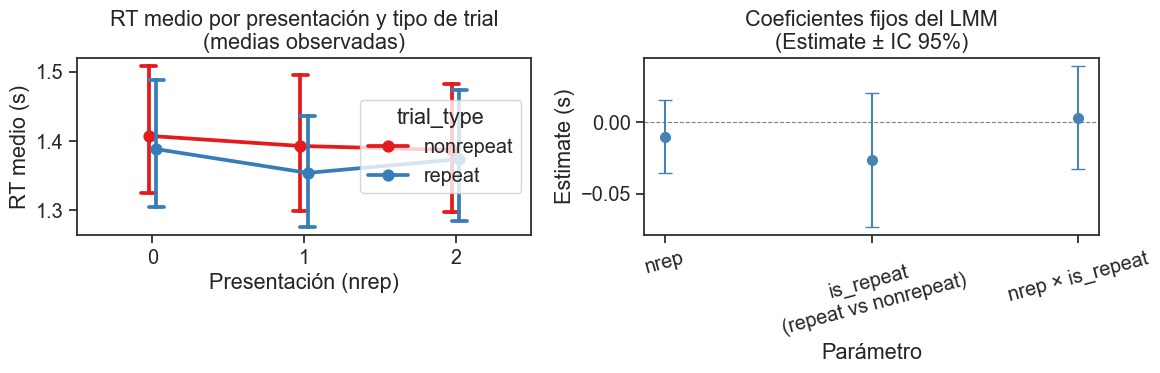


Interpretación de los efectos fijos:
  nrep                      β=-0.0102  p=0.4343  → n.s.
  is_repeat                 β=-0.0268  p=0.2616  → n.s.
  nrep:is_repeat            β=+0.0031  p=0.8682  → n.s.


In [6]:
# ── Celda 6: Plot RT ────────────────────────────────────────────────────────
coefs_rt_pd = coefs_rt.to_pandas()
coefs_rt_pd = coefs_rt_pd[coefs_rt_pd["term"] != "(Intercept)"].copy()

avg_rt = df_rt.groupby(["subj","nrep","trial_type"], as_index=False)["RT"].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.pointplot(data=avg_rt, x="nrep", y="RT", hue="trial_type",
              dodge=True, capsize=0.1, palette="Set1", ax=axes[0])
axes[0].set_title("RT medio por presentación y tipo de trial\n(medias observadas)")
axes[0].set_xlabel("Presentación (nrep)")
axes[0].set_ylabel("RT medio (s)")

axes[1].axhline(0, color="gray", linestyle="--", linewidth=0.8)
axes[1].errorbar(
    x=range(len(coefs_rt_pd)),
    y=coefs_rt_pd["estimate"],
    yerr=[coefs_rt_pd["estimate"] - coefs_rt_pd["conf_low"],
          coefs_rt_pd["conf_high"] - coefs_rt_pd["estimate"]],
    fmt="o", color="steelblue", capsize=5, linewidth=1.5, markersize=7
)
axes[1].set_title("Coeficientes fijos del LMM\n(Estimate ± IC 95%)")
axes[1].set_xlabel("Parámetro")
axes[1].set_ylabel("Estimate (s)")
axes[1].set_xticks(range(len(coefs_rt_pd)))
axes[1].set_xticklabels(
    ["nrep", "is_repeat\n(repeat vs nonrepeat)", "nrep × is_repeat"],
    rotation=15)
plt.tight_layout()
plt.show()

print("\nInterpretación de los efectos fijos:")
for _, row in coefs_rt_pd.iterrows():
    sig = "✓ SIGNIFICATIVO" if row["p_value"] < 0.05 else "n.s."
    print(f"  {row['term']:25s} β={row['estimate']:+.4f}  p={row['p_value']:.4f}  → {sig}")

In [7]:
# ── Celda 7: GLMM sobre precisión ──────────────────────────────────────────
# Modelo: correct ~ nrep * is_repeat + (1|subj)
# glmer = variable binaria, equivalente a glmer(family=binomial) en R

md_correct = glmer("correct ~ nrep * is_repeat + (1|subj)",
                   data=pl.from_pandas(df_rt),
                   family="binomial")
md_correct.fit()

coefs_correct = md_correct.result_fit
print(coefs_correct)

shape: (4, 8)
┌────────────────┬───────────┬───────────┬───────────┬───────────┬───────────┬─────┬────────────┐
│ term           ┆ estimate  ┆ std_error ┆ conf_low  ┆ conf_high ┆ z_stat    ┆ df  ┆ p_value    │
│ ---            ┆ ---       ┆ ---       ┆ ---       ┆ ---       ┆ ---       ┆ --- ┆ ---        │
│ str            ┆ f64       ┆ f64       ┆ f64       ┆ f64       ┆ f64       ┆ f64 ┆ f64        │
╞════════════════╪═══════════╪═══════════╪═══════════╪═══════════╪═══════════╪═════╪════════════╡
│ (Intercept)    ┆ 0.992222  ┆ 0.06429   ┆ 0.866217  ┆ 1.118227  ┆ 15.433632 ┆ inf ┆ 9.7240e-54 │
│ nrep           ┆ 0.041651  ┆ 0.048804  ┆ -0.054003 ┆ 0.137305  ┆ 0.853429  ┆ inf ┆ 0.393421   │
│ is_repeat      ┆ -0.081489 ┆ 0.087597  ┆ -0.253176 ┆ 0.090197  ┆ -0.930276 ┆ inf ┆ 0.352228   │
│ nrep:is_repeat ┆ -0.015072 ┆ 0.068206  ┆ -0.148754 ┆ 0.11861   ┆ -0.220971 ┆ inf ┆ 0.825115   │
└────────────────┴───────────┴───────────┴───────────┴───────────┴───────────┴─────┴────────────┘


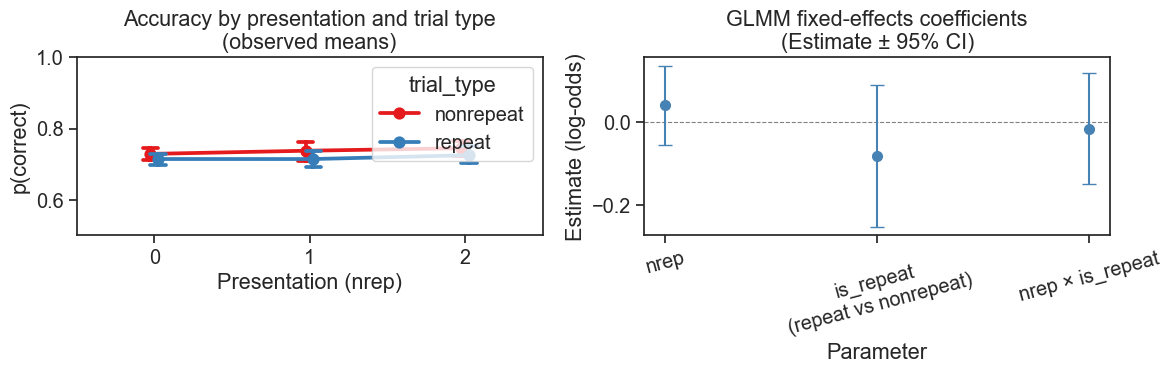


Interpretation (log-odds):
  nrep                      β=+0.0417  p=0.3934  → n.s.
  is_repeat                 β=-0.0815  p=0.3522  → n.s.
  nrep:is_repeat            β=-0.0151  p=0.8251  → n.s.


In [49]:
# ── Cell 8: Plot accuracy ──────────────────────────────────────────────────────
coefs_correct_pd = coefs_correct.to_pandas()
coefs_correct_pd = coefs_correct_pd[coefs_correct_pd["term"] != "(Intercept)"].copy()
avg_correct = df_rt.groupby(["subj","nrep","trial_type"], as_index=False)["correct"].mean()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.pointplot(data=avg_correct, x="nrep", y="correct", hue="trial_type",
              dodge=True, capsize=0.1, palette="Set1", ax=axes[0])
axes[0].set_title("Accuracy by presentation and trial type\n(observed means)")
axes[0].set_xlabel("Presentation (nrep)")
axes[0].set_ylabel("p(correct)")
axes[0].set_ylim(0.5, 1.0)
axes[1].axhline(0, color="gray", linestyle="--", linewidth=0.8)
axes[1].errorbar(
    x=range(len(coefs_correct_pd)),
    y=coefs_correct_pd["estimate"],
    yerr=[coefs_correct_pd["estimate"] - coefs_correct_pd["conf_low"],
          coefs_correct_pd["conf_high"] - coefs_correct_pd["estimate"]],
    fmt="o", color="steelblue", capsize=5, linewidth=1.5, markersize=7
)
axes[1].set_title("GLMM fixed-effects coefficients\n(Estimate ± 95% CI)")
axes[1].set_xticks(range(len(coefs_correct_pd)))
axes[1].set_xticklabels(
    ["nrep", "is_repeat\n(repeat vs nonrepeat)", "nrep × is_repeat"],
    rotation=15)
axes[1].set_xlabel("Parameter")
axes[1].set_ylabel("Estimate (log-odds)")
plt.tight_layout()
plt.show()
print("\nInterpretation (log-odds):")
for _, row in coefs_correct_pd.iterrows():
    sig = "✓ SIGNIFICANT" if row["p_value"] < 0.05 else "n.s."
    print(f"  {row['term']:25s} β={row['estimate']:+.4f}  p={row['p_value']:.4f}  → {sig}")

Psychometric GLMM: deci ~ rDV_z * nrep + (1|subj)
shape: (4, 8)
┌─────────────┬───────────┬───────────┬───────────┬───────────┬───────────┬─────┬─────────────┐
│ term        ┆ estimate  ┆ std_error ┆ conf_low  ┆ conf_high ┆ z_stat    ┆ df  ┆ p_value     │
│ ---         ┆ ---       ┆ ---       ┆ ---       ┆ ---       ┆ ---       ┆ --- ┆ ---         │
│ str         ┆ f64       ┆ f64       ┆ f64       ┆ f64       ┆ f64       ┆ f64 ┆ f64         │
╞═════════════╪═══════════╪═══════════╪═══════════╪═══════════╪═══════════╪═════╪═════════════╡
│ (Intercept) ┆ 0.394831  ┆ 0.129813  ┆ 0.140401  ┆ 0.64926   ┆ 3.041522  ┆ inf ┆ 0.002354    │
│ rDV_z       ┆ 1.326777  ┆ 0.055853  ┆ 1.217307  ┆ 1.436246  ┆ 23.754821 ┆ inf ┆ 9.7966e-125 │
│ nrep        ┆ -0.018982 ┆ 0.03764   ┆ -0.092756 ┆ 0.054791  ┆ -0.504302 ┆ inf ┆ 0.614049    │
│ rDV_z:nrep  ┆ 0.064524  ┆ 0.043422  ┆ -0.020583 ┆ 0.14963   ┆ 1.485954  ┆ inf ┆ 0.137291    │
└─────────────┴───────────┴───────────┴───────────┴───────────┴─────────

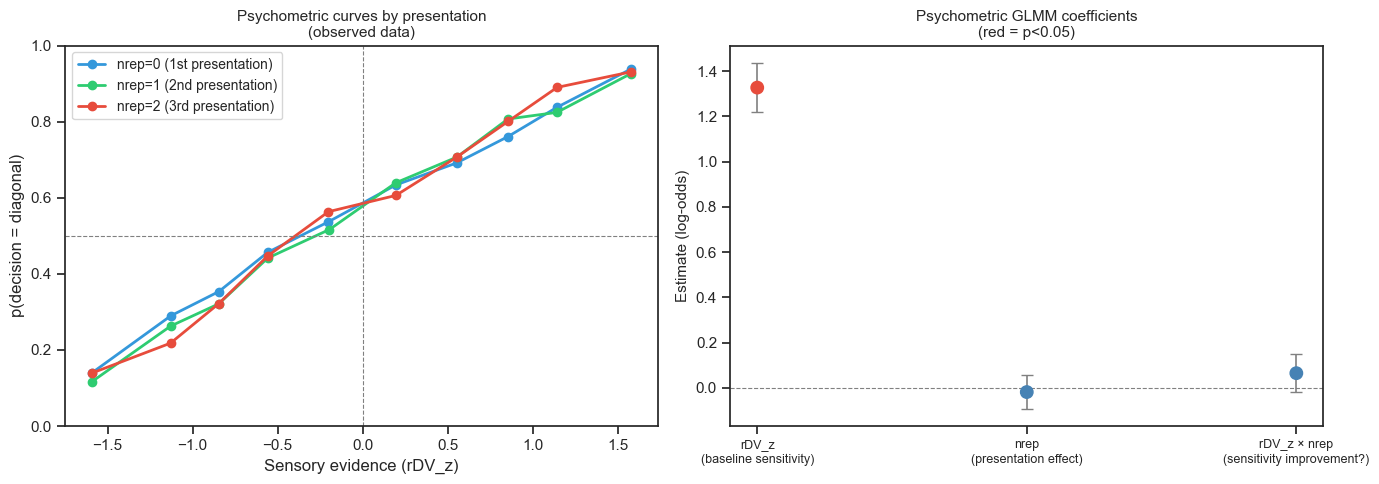


Interaction rDV_z × nrep: β=+0.0645, p=0.1373
→ Does sensitivity improve with nrep? NO → sensitivity does not change significantly across presentations


In [80]:
# ── Cell 8b: Psychometric curves by presentation (nrep) ──────────────────
# To check whether there is a real improvement in sensitivity, plot
# p(decision = 1) as a function of rDV, separated by nrep (0, 1, 2)
# If sensitivity improves, curves will be steeper with each nrep

from scipy.special import expit  # sigmoid

# We standardize rDV globally for the plot (already available per subject as rDV_z)
# Here we use rDV_z (standardized per participant) as the x-axis
# We create bins of rDV_z to average p(deci=1) within each bin

n_bins = 10
df_rt["rDV_bin"] = pd.qcut(df_rt["rDV_z"], q=n_bins, labels=False, duplicates="drop")

# Average p(deci=1) per participant, nrep and bin
psy_data = df_rt.groupby(["subj", "nrep", "rDV_bin"], as_index=False).agg(
    p_deci=("deci", "mean"),
    rDV_mean=("rDV_z", "mean")
)

# Average across participants for the plot
psy_avg = psy_data.groupby(["nrep", "rDV_bin"], as_index=False).agg(
    p_deci=("p_deci", "mean"),
    rDV_mean=("rDV_mean", "mean")
)

# Psychometric GLMM: deci ~ rDV_z * nrep + (1|subj)
# To estimate whether the slope (sensitivity) increases with nrep
md_psy = glmer(
    "deci ~ rDV_z * nrep + (1|subj)",
    data=pl.from_pandas(df_rt),
    family="binomial"
)
md_psy.fit()
coefs_psy = md_psy.result_fit.to_pandas()

print("Psychometric GLMM: deci ~ rDV_z * nrep + (1|subj)")
print(md_psy.result_fit)
print("\nInterpretation:")
for _, row in coefs_psy[coefs_psy["term"] != "(Intercept)"].iterrows():
    sig = "✓ SIGNIFICANT" if row["p_value"] < 0.05 else "n.s."
    print(f"  {row['term']:25s} β={row['estimate']:+.4f}  p={row['p_value']:.4f}  → {sig}")

# ── Plot ────────────────────────────────────────────────────────────────────
palette_nrep = {0: "#3498db", 1: "#2ecc71", 2: "#e74c3c"}
labels_nrep  = {0: "nrep=0 (1st presentation)",
                1: "nrep=1 (2nd presentation)",
                2: "nrep=2 (3rd presentation)"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: observed psychometric curves
for nrep_val, color in palette_nrep.items():
    d = psy_avg[psy_avg["nrep"] == nrep_val]
    if len(d) == 0:
        continue
    axes[0].plot(d["rDV_mean"], d["p_deci"], "o-",
                 color=color, label=labels_nrep[nrep_val],
                 linewidth=2, markersize=6)

axes[0].axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
axes[0].axvline(0,   color="gray", linestyle="--", linewidth=0.8)
axes[0].set_xlabel("Sensory evidence (rDV_z)", fontsize=12)
axes[0].set_ylabel("p(decision = diagonal)", fontsize=12)
axes[0].set_title("Psychometric curves by presentation\n(observed data)", fontsize=11)
axes[0].legend(fontsize=10)
axes[0].set_ylim(0, 1)

# Right: GLMM coefficients (rDV_z slope and rDV_z:nrep interaction)
coefs_psy_plot = coefs_psy[coefs_psy["term"].isin(["rDV_z", "nrep", "rDV_z:nrep"])].copy()
colors_psy = ["#e74c3c" if p < 0.05 else "steelblue" for p in coefs_psy_plot["p_value"]]

axes[1].axhline(0, color="gray", linestyle="--", linewidth=0.8)
axes[1].errorbar(
    x=range(len(coefs_psy_plot)),
    y=coefs_psy_plot["estimate"],
    yerr=[coefs_psy_plot["estimate"] - coefs_psy_plot["conf_low"],
          coefs_psy_plot["conf_high"] - coefs_psy_plot["estimate"]],
    fmt="none", color="gray", capsize=4, linewidth=1.2, zorder=1
)
axes[1].scatter(range(len(coefs_psy_plot)), coefs_psy_plot["estimate"],
                color=colors_psy, s=80, zorder=2)
axes[1].set_xticks(range(len(coefs_psy_plot)))
axes[1].set_xticklabels(
    ["rDV_z\n(baseline sensitivity)", "nrep\n(presentation effect)", "rDV_z × nrep\n(sensitivity improvement?)"],
    fontsize=9)
axes[1].set_ylabel("Estimate (log-odds)", fontsize=11)
axes[1].set_title("Psychometric GLMM coefficients\n(red = p<0.05)", fontsize=11)

plt.tight_layout()
plt.show()

# Key interpretation
rdv_nrep = coefs_psy[coefs_psy["term"] == "rDV_z:nrep"]
if len(rdv_nrep) > 0:
    b = rdv_nrep["estimate"].values[0]
    p = rdv_nrep["p_value"].values[0]
    sig = "YES → sensitivity improves across presentations" if p < 0.05 else "NO → sensitivity does not change significantly across presentations"
    print(f"\nInteraction rDV_z × nrep: β={b:+.4f}, p={p:.4f}")
    print(f"→ Does sensitivity improve with nrep? {sig}")

In [28]:
"""# ── Celda 9: GLMM principal — Confirmation Bias ─────────────────────────────
# Solo nrep > 0 (necesitamos decisión previa)
# Modelo: deci ~ rDV_z * deci1_c * is_repeat * nrep + (1|subj)

df_rep = df_rt[df_rt["nrep"] > 0].dropna(
    subset=["deci1_c", "rDV_z", "is_repeat"]
).copy()

md_deci = glmer(
    "deci ~ rDV_z * deci1_c * is_repeat * nrep + (1|subj)",
    data=pl.from_pandas(df_rep),
    family="binomial"
)
md_deci.fit()

coefs_deci = md_deci.result_fit
coefs_deci_pd = coefs_deci.to_pandas()
print(coefs_deci)

print("\nEfectos significativos (p < 0.05):")
sig = coefs_deci_pd[coefs_deci_pd["p_value"] < 0.05]
for _, row in sig.iterrows():
    print(f"  {row['term']:35s} β={row['estimate']:+.4f}  p={row['p_value']:.4f}")"""

# ── Celda 9: GLMM principal — Confirmation Bias ─────────────────────────────

# nrep como variable CATEGÓRICA (factor) con nrep=0 como referencia
# → salen nrep_f1 y nrep_f2 como coeficientes separados
# Modelo: deci ~ rDV_z * deci1_c * is_repeat * nrep_f + (1|subj)

df_rep = df_rt.copy()

# Convertir nrep a categórica con nrep=0 como referencia
df_rep["nrep_f"] = pd.Categorical(df_rep["nrep"].astype(str),
                                   categories=["0", "1", "2"],
                                   ordered=False)

# Eliminar NaN en las variables del modelo (nrep=0 tendrá NaN en deci1_c → el modelo los descarta solo)
df_rep = df_rep.dropna(subset=["rDV_z", "is_repeat"]).copy()

md_deci = glmer(
    "deci ~ rDV_z * deci1_c * is_repeat * nrep_f + (1|subj)",
    data=pl.from_pandas(df_rep),
    family="binomial"
)
md_deci.fit()

coefs_deci    = md_deci.result_fit
coefs_deci_pd = coefs_deci.to_pandas()
print(coefs_deci)

print("\nEfectos significativos (p < 0.05):")
sig = coefs_deci_pd[coefs_deci_pd["p_value"] < 0.05]
for _, row in sig.iterrows():
    print(f"  {row['term']:35s} β={row['estimate']:+.4f}  p={row['p_value']:.4f}")

R messages: 
Derivatives (gradient and/or Hessian) not available. Cannot assess
  convergence through gradient-based checks.

Convergence status
: [1] FALSE
attr(,"gradient")
[1] NA

R messages: 
Derivatives (gradient and/or Hessian) not available. Cannot assess
  convergence through gradient-based checks.

Convergence status
: [1] FALSE
attr(,"gradient")
[1] NA

shape: (24, 8)
┌───────────────────┬───────────┬───────────┬───────────┬───────────┬───────────┬─────┬────────────┐
│ term              ┆ estimate  ┆ std_error ┆ conf_low  ┆ conf_high ┆ z_stat    ┆ df  ┆ p_value    │
│ ---               ┆ ---       ┆ ---       ┆ ---       ┆ ---       ┆ ---       ┆ --- ┆ ---        │
│ str               ┆ f64       ┆ f64       ┆ f64       ┆ f64       ┆ f64       ┆ f64 ┆ f64        │
╞═══════════════════╪═══════════╪═══════════╪═══════════╪═══════════╪═══════════╪═════╪════════════╡
│ (Intercept)       ┆ 0.396363  ┆ 0.121119  ┆ 0.158974  ┆ 0.633753  ┆ 3.272506  ┆ inf ┆ 0.001066   │
│ rDV_z      

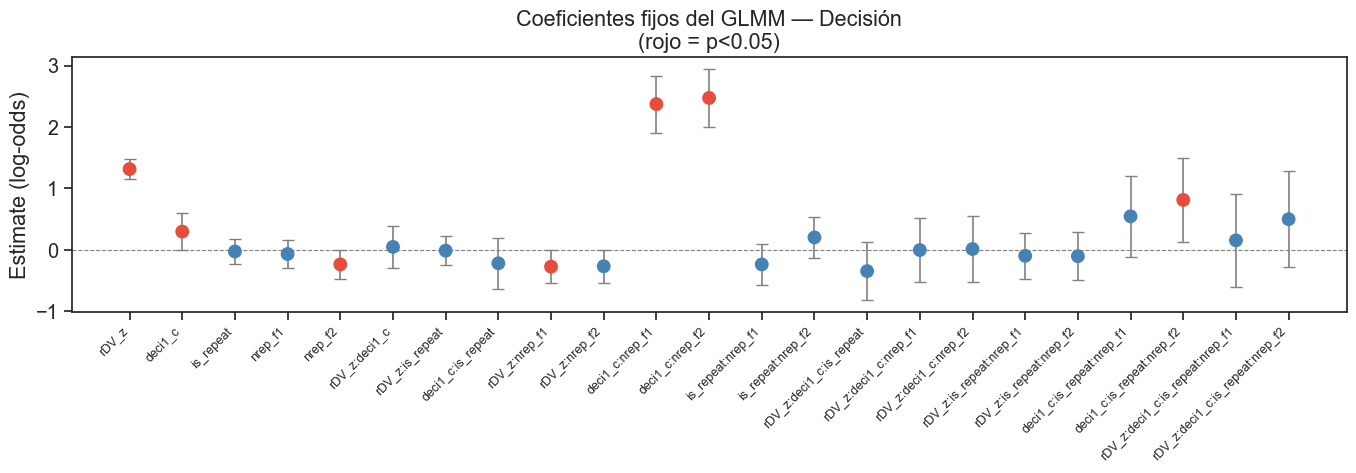

In [29]:
# ── Celda 10: Plot modelo principal ─────────────────────────────────────────
coefs_plot = coefs_deci_pd[coefs_deci_pd["term"] != "(Intercept)"].copy()
colors = ["#e74c3c" if p < 0.05 else "steelblue" for p in coefs_plot["p_value"]]

fig, ax = plt.subplots(figsize=(14, 5))
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.errorbar(
    x=range(len(coefs_plot)),
    y=coefs_plot["estimate"],
    yerr=[coefs_plot["estimate"] - coefs_plot["conf_low"],
          coefs_plot["conf_high"] - coefs_plot["estimate"]],
    fmt="none", color="gray", capsize=4, linewidth=1.2, zorder=1
)
ax.scatter(range(len(coefs_plot)), coefs_plot["estimate"],
           color=colors, s=80, zorder=2)
ax.set_xticks(range(len(coefs_plot)))
ax.set_xticklabels(coefs_plot["term"], rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Estimate (log-odds)")
ax.set_title("Coeficientes fijos del GLMM — Decisión\n(rojo = p<0.05)")
plt.tight_layout()
plt.show()

In [11]:
# ── Celda 11: GLMM Switch ───────────────────────────────────────────────────
# Modelo: switch ~ nrep * is_repeat + (1|subj)

md_switch = glmer(
    "switch ~ nrep * is_repeat + (1|subj)",
    data=pl.from_pandas(df_rep),
    family="binomial"
)
md_switch.fit()

coefs_switch    = md_switch.result_fit
coefs_switch_pd = coefs_switch.to_pandas()
print(coefs_switch)

# p(switch) basal = sigmoid(Intercept)
intercept   = coefs_switch_pd.loc[coefs_switch_pd["term"]=="(Intercept)", "estimate"].values[0]
p_switch    = 1 / (1 + np.exp(-intercept))
print(f"\np(cambiar decisión) basal: {p_switch:.3f}")
print(f"p(repetir decisión) basal: {1-p_switch:.3f}")

shape: (4, 8)
┌────────────────┬───────────┬───────────┬───────────┬───────────┬───────────┬─────┬────────────┐
│ term           ┆ estimate  ┆ std_error ┆ conf_low  ┆ conf_high ┆ z_stat    ┆ df  ┆ p_value    │
│ ---            ┆ ---       ┆ ---       ┆ ---       ┆ ---       ┆ ---       ┆ --- ┆ ---        │
│ str            ┆ f64       ┆ f64       ┆ f64       ┆ f64       ┆ f64       ┆ f64 ┆ f64        │
╞════════════════╪═══════════╪═══════════╪═══════════╪═══════════╪═══════════╪═════╪════════════╡
│ (Intercept)    ┆ -1.667637 ┆ 0.21897   ┆ -2.09681  ┆ -1.238463 ┆ -7.615817 ┆ inf ┆ 2.6203e-14 │
│ nrep           ┆ -0.091409 ┆ 0.120424  ┆ -0.327436 ┆ 0.144618  ┆ -0.759057 ┆ inf ┆ 0.447818   │
│ is_repeat      ┆ -0.030122 ┆ 0.273841  ┆ -0.566841 ┆ 0.506597  ┆ -0.109998 ┆ inf ┆ 0.912411   │
│ nrep:is_repeat ┆ -0.0996   ┆ 0.17582   ┆ -0.4442   ┆ 0.245001  ┆ -0.566487 ┆ inf ┆ 0.571063   │
└────────────────┴───────────┴───────────┴───────────┴───────────┴───────────┴─────┴────────────┘

p(cam

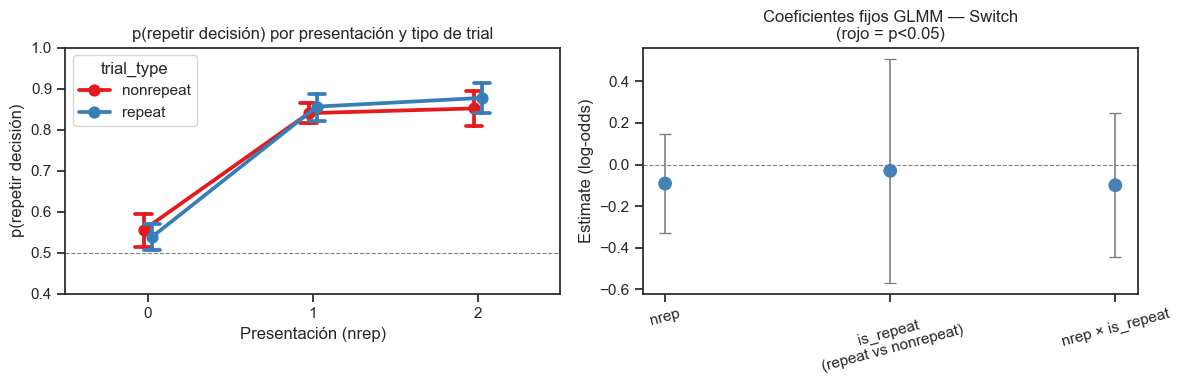


Interpretación:
  nrep                      β=-0.0914  p=0.4478  → n.s.
  is_repeat                 β=-0.0301  p=0.9124  → n.s.
  nrep:is_repeat            β=-0.0996  p=0.5711  → n.s.


In [70]:
# ── Celda 12: Plot Switch ───────────────────────────────────────────────────
avg_switch = df_rep.groupby(["subj","nrep","trial_type"], as_index=False)["switch"].mean()
avg_switch["p_repeat"] = 1 - avg_switch["switch"]

coefs_sw_plot = coefs_switch_pd[coefs_switch_pd["term"] != "(Intercept)"].copy()
colors_sw     = ["#e74c3c" if p < 0.05 else "steelblue" for p in coefs_sw_plot["p_value"]]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.pointplot(data=avg_switch, x="nrep", y="p_repeat", hue="trial_type",
              dodge=True, capsize=0.1, palette="Set1", ax=axes[0])
axes[0].axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
axes[0].set_title("p(repetir decisión) por presentación y tipo de trial")
axes[0].set_xlabel("Presentación (nrep)")
axes[0].set_ylabel("p(repetir decisión)")
axes[0].set_ylim(0.4, 1.0)

axes[1].axhline(0, color="gray", linestyle="--", linewidth=0.8)
axes[1].errorbar(
    x=range(len(coefs_sw_plot)),
    y=coefs_sw_plot["estimate"],
    yerr=[coefs_sw_plot["estimate"] - coefs_sw_plot["conf_low"],
          coefs_sw_plot["conf_high"] - coefs_sw_plot["estimate"]],
    fmt="none", color="gray", capsize=4, linewidth=1.2, zorder=1
)
axes[1].scatter(range(len(coefs_sw_plot)), coefs_sw_plot["estimate"],
                color=colors_sw, s=80, zorder=2)
axes[1].set_xticks(range(len(coefs_sw_plot)))
axes[1].set_xticklabels(
    ["nrep", "is_repeat\n(repeat vs nonrepeat)", "nrep × is_repeat"],
    rotation=15)
axes[1].set_ylabel("Estimate (log-odds)")
axes[1].set_title("Coeficientes fijos GLMM — Switch\n(rojo = p<0.05)")
plt.tight_layout()
plt.show()

print("\nInterpretación:")
for _, row in coefs_sw_plot.iterrows():
    sig = "✓ SIGNIFICATIVO" if row["p_value"] < 0.05 else "n.s."
    print(f"  {row['term']:25s} β={row['estimate']:+.4f}  p={row['p_value']:.4f}  → {sig}")

In [71]:
# ── Celda 11: GLMM Switch ───────────────────────────────────────────────────
# Modelo: switch ~ rDV_z * nrep * is_repeat + (1|subj)
# rDV_z: evidencia sensorial del trial actual (valor absoluto = "cardinalidad/diagonalidad")
# La interacción rDV_z × nrep nos dice si el slope cambia con las presentaciones
# La interacción rDV_z × is_repeat nos dice si el slope difiere según tipo de trial

md_switch = glmer(
    "switch ~ rDV_z * nrep * is_repeat + (1|subj)",
    data=pl.from_pandas(df_rep),
    family="binomial"
)
md_switch.fit()

coefs_switch    = md_switch.result_fit
coefs_switch_pd = coefs_switch.to_pandas()
print(coefs_switch)

# p(switch) basal = sigmoid(Intercept)
intercept = coefs_switch_pd.loc[coefs_switch_pd["term"] == "(Intercept)", "estimate"].values[0]
p_switch  = 1 / (1 + np.exp(-intercept))
print(f"\np(cambiar decisión) basal: {p_switch:.3f}")
print(f"p(repetir decisión) basal: {1 - p_switch:.3f}")

print("\nEfectos significativos (p < 0.05):")
sig_sw = coefs_switch_pd[coefs_switch_pd["p_value"] < 0.05]
for _, row in sig_sw.iterrows():
    print(f"  {row['term']:35s} β={row['estimate']:+.4f}  p={row['p_value']:.4f}")

shape: (8, 8)
┌──────────────────┬───────────┬───────────┬───────────┬───────────┬────────────┬─────┬────────────┐
│ term             ┆ estimate  ┆ std_error ┆ conf_low  ┆ conf_high ┆ z_stat     ┆ df  ┆ p_value    │
│ ---              ┆ ---       ┆ ---       ┆ ---       ┆ ---       ┆ ---        ┆ --- ┆ ---        │
│ str              ┆ f64       ┆ f64       ┆ f64       ┆ f64       ┆ f64        ┆ f64 ┆ f64        │
╞══════════════════╪═══════════╪═══════════╪═══════════╪═══════════╪════════════╪═════╪════════════╡
│ (Intercept)      ┆ -0.375073 ┆ 0.078794  ┆ -0.529507 ┆ -0.220639 ┆ -4.760143  ┆ inf ┆ 0.000002   │
│ rDV_z            ┆ -0.11963  ┆ 0.059145  ┆ -0.235552 ┆ -0.003708 ┆ -2.022657  ┆ inf ┆ 0.043109   │
│ nrep             ┆ -0.861386 ┆ 0.05576   ┆ -0.970674 ┆ -0.752099 ┆ -15.448097 ┆ inf ┆ 7.7704e-54 │
│ is_repeat        ┆ 0.078793  ┆ 0.08306   ┆ -0.084001 ┆ 0.241588  ┆ 0.94863    ┆ inf ┆ 0.342809   │
│ rDV_z:nrep       ┆ -0.015633 ┆ 0.05582   ┆ -0.125038 ┆ 0.093771  ┆ -0.28006

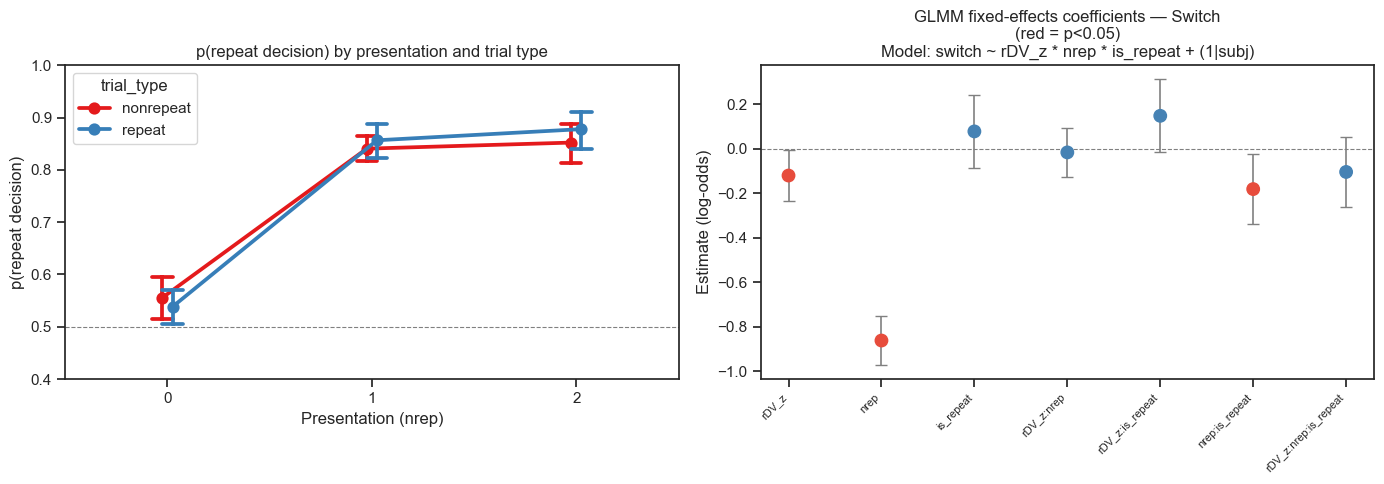


Interpretation:
  rDV_z                               β=-0.1196  p=0.0431  → ✓ SIGNIFICANT
  nrep                                β=-0.8614  p=0.0000  → ✓ SIGNIFICANT
  is_repeat                           β=+0.0788  p=0.3428  → n.s.
  rDV_z:nrep                          β=-0.0156  p=0.7794  → n.s.
  rDV_z:is_repeat                     β=+0.1488  p=0.0741  → n.s.
  nrep:is_repeat                      β=-0.1806  p=0.0259  → ✓ SIGNIFICANT
  rDV_z:nrep:is_repeat                β=-0.1035  p=0.2017  → n.s.


In [73]:
# ── Cell 12: Plot Switch ─────────────────────────────────────────────────────
avg_switch = df_rep.groupby(["subj", "nrep", "trial_type"], as_index=False)["switch"].mean()
avg_switch["p_repeat"] = 1 - avg_switch["switch"]

coefs_sw_plot = coefs_switch_pd[coefs_switch_pd["term"] != "(Intercept)"].copy().reset_index(drop=True)
colors_sw     = ["#e74c3c" if p < 0.05 else "steelblue" for p in coefs_sw_plot["p_value"]]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: observed p(repeat) ─────────────────────────────────────────────────
sns.pointplot(data=avg_switch, x="nrep", y="p_repeat", hue="trial_type",
              dodge=True, capsize=0.1, palette="Set1", ax=axes[0])
axes[0].axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
axes[0].set_title("p(repeat decision) by presentation and trial type")
axes[0].set_xlabel("Presentation (nrep)")
axes[0].set_ylabel("p(repeat decision)")
axes[0].set_ylim(0.4, 1.0)

# ── Right: GLMM fixed-effects coefficients ───────────────────────────────────
axes[1].axhline(0, color="gray", linestyle="--", linewidth=0.8)
axes[1].errorbar(
    x=range(len(coefs_sw_plot)),
    y=coefs_sw_plot["estimate"],
    yerr=[coefs_sw_plot["estimate"] - coefs_sw_plot["conf_low"],
          coefs_sw_plot["conf_high"] - coefs_sw_plot["estimate"]],
    fmt="none", color="gray", capsize=4, linewidth=1.2, zorder=1
)
axes[1].scatter(range(len(coefs_sw_plot)), coefs_sw_plot["estimate"],
                color=colors_sw, s=80, zorder=2)
axes[1].set_xticks(range(len(coefs_sw_plot)))
axes[1].set_xticklabels(coefs_sw_plot["term"], rotation=45, ha="right", fontsize=8)
axes[1].set_ylabel("Estimate (log-odds)")
axes[1].set_title("GLMM fixed-effects coefficients — Switch\n(red = p<0.05)\nModel: switch ~ rDV_z * nrep * is_repeat + (1|subj)")

plt.tight_layout()
plt.show()

print("\nInterpretation:")
for _, row in coefs_sw_plot.iterrows():
    sig = "✓ SIGNIFICANT" if row["p_value"] < 0.05 else "n.s."
    print(f"  {row['term']:35s} β={row['estimate']:+.4f}  p={row['p_value']:.4f}  → {sig}")

In [13]:
# ── Celda 13: GLMM Confianza → Switch ──────────────────────────────────────
# Modelo: switch ~ confi1_z * nrep * is_repeat + (1|subj)

df_confi = df_rt[df_rt["nrep"] > 0].copy()
df_confi = df_confi.dropna(subset=["confi-1"]).reset_index(drop=True)
df_confi["confi1_z"] = df_confi.groupby("subj")["confi-1"].transform(
    lambda x: (x - x.mean()) / x.std())

print(f"Trials: {len(df_confi)} | Participantes: {df_confi['subj'].nunique()}")

md_confi = glmer(
    "switch ~ confi1_z * nrep * is_repeat + (1|subj)",
    data=pl.from_pandas(df_confi),
    family="binomial"
)
md_confi.fit()

coefs_confi    = md_confi.result_fit
coefs_confi_pd = coefs_confi.to_pandas()
print(coefs_confi)

print("\nInterpretación:")
for _, row in coefs_confi_pd[coefs_confi_pd["term"] != "(Intercept)"].iterrows():
    sig = "✓ SIGNIFICATIVO" if row["p_value"] < 0.05 else "n.s."
    print(f"  {row['term']:30s} β={row['estimate']:+.4f}  p={row['p_value']:.4f}  → {sig}")

Trials: 4370 | Participantes: 25
shape: (8, 8)
┌───────────────────┬───────────┬───────────┬───────────┬───────────┬───────────┬─────┬────────────┐
│ term              ┆ estimate  ┆ std_error ┆ conf_low  ┆ conf_high ┆ z_stat    ┆ df  ┆ p_value    │
│ ---               ┆ ---       ┆ ---       ┆ ---       ┆ ---       ┆ ---       ┆ --- ┆ ---        │
│ str               ┆ f64       ┆ f64       ┆ f64       ┆ f64       ┆ f64       ┆ f64 ┆ f64        │
╞═══════════════════╪═══════════╪═══════════╪═══════════╪═══════════╪═══════════╪═════╪════════════╡
│ (Intercept)       ┆ -2.213715 ┆ 0.256092  ┆ -2.715646 ┆ -1.711784 ┆ -8.644216 ┆ inf ┆ 5.4176e-18 │
│ confi1_z          ┆ -0.977478 ┆ 0.211207  ┆ -1.391436 ┆ -0.56352  ┆ -4.628055 ┆ inf ┆ 0.000004   │
│ nrep              ┆ 0.145381  ┆ 0.138572  ┆ -0.126216 ┆ 0.416978  ┆ 1.049134  ┆ inf ┆ 0.294117   │
│ is_repeat         ┆ 0.191185  ┆ 0.327877  ┆ -0.451443 ┆ 0.833812  ┆ 0.583099  ┆ inf ┆ 0.559827   │
│ confi1_z:nrep     ┆ 0.182223  ┆ 0.134097  

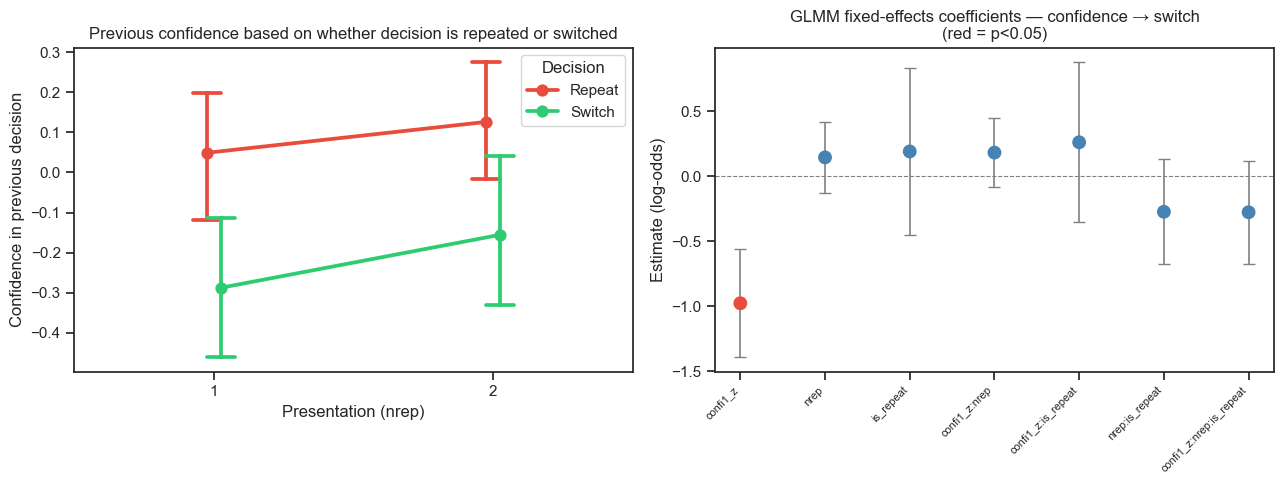

In [75]:
# ── Cell 14: Plot Confidence → Switch ────────────────────────────────────────
avg_confi_switch = df_confi.groupby(
    ["subj", "nrep", "switch"], as_index=False
)["confi-1"].mean()
coefs_cf_plot = coefs_confi_pd[coefs_confi_pd["term"] != "(Intercept)"].copy()
colors_cf     = ["#e74c3c" if p < 0.05 else "steelblue" for p in coefs_cf_plot["p_value"]]
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.pointplot(data=avg_confi_switch, x="nrep", y="confi-1", hue="switch",
              dodge=True, capsize=0.1,
              palette={0: "#e74c3c", 1: "#2ecc71"}, ax=axes[0])
axes[0].set_title("Previous confidence based on whether decision is repeated or switched")
axes[0].set_xlabel("Presentation (nrep)")
axes[0].set_ylabel("Confidence in previous decision")
handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles, ["Repeat", "Switch"], title="Decision")
axes[1].axhline(0, color="gray", linestyle="--", linewidth=0.8)
axes[1].errorbar(
    x=range(len(coefs_cf_plot)),
    y=coefs_cf_plot["estimate"],
    yerr=[coefs_cf_plot["estimate"] - coefs_cf_plot["conf_low"],
          coefs_cf_plot["conf_high"] - coefs_cf_plot["estimate"]],
    fmt="none", color="gray", capsize=4, linewidth=1.2, zorder=1
)
axes[1].scatter(range(len(coefs_cf_plot)), coefs_cf_plot["estimate"],
                color=colors_cf, s=80, zorder=2)
axes[1].set_xticks(range(len(coefs_cf_plot)))
axes[1].set_xticklabels(coefs_cf_plot["term"], rotation=45, ha="right", fontsize=8)
axes[1].set_ylabel("Estimate (log-odds)")
axes[1].set_title("GLMM fixed-effects coefficients — confidence → switch\n(red = p<0.05)")
plt.tight_layout()
plt.show()

In [15]:
# ── Celda 15: Peso de cada estímulo ─────────────────────────────────────────
# Modelo: deci ~ deci1_c + d1_z + ... + d6_z + (1|subj) por nrep
# deci1_c controla el sesgo → betas de d1-d6 = peso sensorial puro

for col in ["d1","d2","d3","d4","d5","d6"]:
    df_rep[f"{col}_z"] = df_rep.groupby("subj")[col].transform(
        lambda x: (x - x.mean()) / x.std())

results_stim = []

for nrep_val in [1, 2]:
    dat = df_rep[df_rep["nrep"] == nrep_val].copy()
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        md = glmer(
            "deci ~ deci1_c + d1_z + d2_z + d3_z + d4_z + d5_z + d6_z + (1|subj)",
            data=pl.from_pandas(dat),
            family="binomial"
        )
        md.fit()

    res = md.result_fit.to_pandas()
    res["nrep"] = nrep_val
    results_stim.append(res)

df_coefs_stim = pd.concat(results_stim, ignore_index=True)
print(df_coefs_stim[["nrep","term","estimate","p_value"]].round(4))

    nrep         term  estimate  p_value
0      1  (Intercept)    0.1964   0.0869
1      1      deci1_c    2.9692   0.0000
2      1         d1_z    0.4381   0.0000
3      1         d2_z    0.3129   0.0000
4      1         d3_z    0.3788   0.0000
5      1         d4_z    0.3729   0.0000
6      1         d5_z    0.4183   0.0000
7      1         d6_z    0.3153   0.0000
8      2  (Intercept)    0.2428   0.0393
9      2      deci1_c    3.1251   0.0000
10     2         d1_z    0.2831   0.0000
11     2         d2_z    0.4235   0.0000
12     2         d3_z    0.4118   0.0000
13     2         d4_z    0.3488   0.0000
14     2         d5_z    0.3487   0.0000
15     2         d6_z    0.4340   0.0000


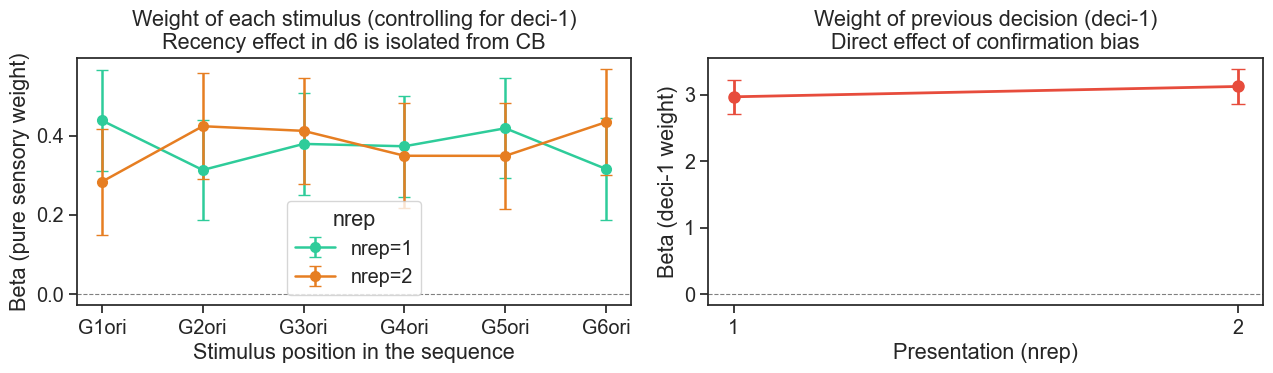

Test deci-1 weight:
  nrep=1: β=+2.9692  p=0.0000  → ✓ SIGNIFICANT
  nrep=2: β=+3.1251  p=0.0000  → ✓ SIGNIFICANT


In [ ]:
# ── Cell 16: Plot stimulus weights ───────────────────────────────────────────
stim_names = ["d1_z","d2_z","d3_z","d4_z","d5_z","d6_z"]
df_stim = df_coefs_stim[df_coefs_stim["term"].isin(stim_names)].copy()
df_deci = df_coefs_stim[df_coefs_stim["term"] == "deci1_c"].copy()
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
palette = {1: "#2ecc9a", 2: "#e67e22"}
for nrep_val, color in palette.items():
    d = df_stim[df_stim["nrep"] == nrep_val]
    axes[0].errorbar(
        x=range(6), y=d["estimate"],
        yerr=[d["estimate"] - d["conf_low"], d["conf_high"] - d["estimate"]],
        fmt="o-", color=color, capsize=4, label=f"nrep={nrep_val}",
        linewidth=1.8, markersize=7
    )
axes[0].axhline(0, color="gray", linestyle="--", linewidth=0.8)
axes[0].set_xticks(range(6))
axes[0].set_xticklabels(["G1ori","G2ori","G3ori","G4ori","G5ori","G6ori"])
axes[0].set_xlabel("Stimulus position in the sequence")
axes[0].set_ylabel("Beta (pure sensory weight)")
axes[0].set_title("Weight of each stimulus (controlling for deci-1)\nRecency effect in d6 is isolated from CB")
axes[0].legend(title="nrep")
axes[1].errorbar(
    x=[0, 1], y=df_deci["estimate"],
    yerr=[df_deci["estimate"] - df_deci["conf_low"],
          df_deci["conf_high"] - df_deci["estimate"]],
    fmt="o-", color="#e74c3c", capsize=5, linewidth=2, markersize=8
)
axes[1].axhline(0, color="gray", linestyle="--", linewidth=0.8)
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["1", "2"])
axes[1].set_xlabel("Presentation (nrep)")
axes[1].set_ylabel("Beta (deci-1 weight)")
axes[1].set_title("Weight of previous decision (deci-1)\nDirect effect of confirmation bias")
plt.tight_layout()                                                                              
plt.show()
print("Test deci-1 weight:")
for _, row in df_deci.iterrows():
    sig = "✓ SIGNIFICANT" if row["p_value"] < 0.05 else "n.s."
    print(f"  nrep={row['nrep']}: β={row['estimate']:+.4f}  p={row['p_value']:.4f}  → {sig}")

In [17]:
# ── Celda 17: CB Index ──────────────────────────────────────────────────────
# Reordenamos estímulos por congruencia con la decisión previa
# G1sim = más congruente, G6sim = más incongruente
# CB_idx = posw(G1,G2) - negw(G5,G6)

prev_deci     = df_rep["deci-1"].copy().replace({0: -1})
orientations  = df_rep[["d1","d2","d3","d4","d5","d6"]].values
prev_respdiff = orientations * prev_deci.values[:, None]
sort_idx      = prev_respdiff.argsort(axis=1)[:, ::-1]
reo_orien     = np.take_along_axis(orientations, sort_idx, axis=1)

reo_df = pd.DataFrame(reo_orien, columns=["G1sim","G2sim","G3sim","G4sim","G5sim","G6sim"])
df_glm = pd.concat([df_rep.reset_index(drop=True), reo_df], axis=1)
df_glm["deci_prev"] = prev_deci.values

for col in ["G1sim","G2sim","G3sim","G4sim","G5sim","G6sim"]:
    df_glm[f"{col}_z"] = df_glm.groupby("subj")[col].transform(
        lambda x: (x - x.mean()) / x.std())

sim_names    = ["G1sim_z","G2sim_z","G3sim_z","G4sim_z","G5sim_z","G6sim_z"]
results_sim  = []

for nrep_val in [1, 2]:
    dat = df_glm[df_glm["nrep"] == nrep_val].copy()
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        md = glmer(
            "deci ~ deci_prev + G1sim_z + G2sim_z + G3sim_z + G4sim_z + G5sim_z + G6sim_z + (1|subj)",
            data=pl.from_pandas(dat),
            family="binomial"
        )
        md.fit()

    res = md.result_fit.to_pandas()
    res["nrep"] = nrep_val
    results_sim.append(res)

df_coefs_sim = pd.concat(results_sim, ignore_index=True)

print("Índice CB por nrep:")
for nrep_val in [1, 2]:
    d    = df_coefs_sim[df_coefs_sim["nrep"] == nrep_val]
    posw = d[d["term"].isin(["G1sim_z","G2sim_z"])]["estimate"].mean()
    negw = d[d["term"].isin(["G5sim_z","G6sim_z"])]["estimate"].mean()
    cb   = posw - negw
    print(f"  nrep={nrep_val}: posw={posw:.4f}, negw={negw:.4f}, CB_idx={cb:.4f}")

Índice CB por nrep:
  nrep=1: posw=-0.0415, negw=0.2383, CB_idx=-0.2798
  nrep=2: posw=0.0314, negw=0.4330, CB_idx=-0.4016


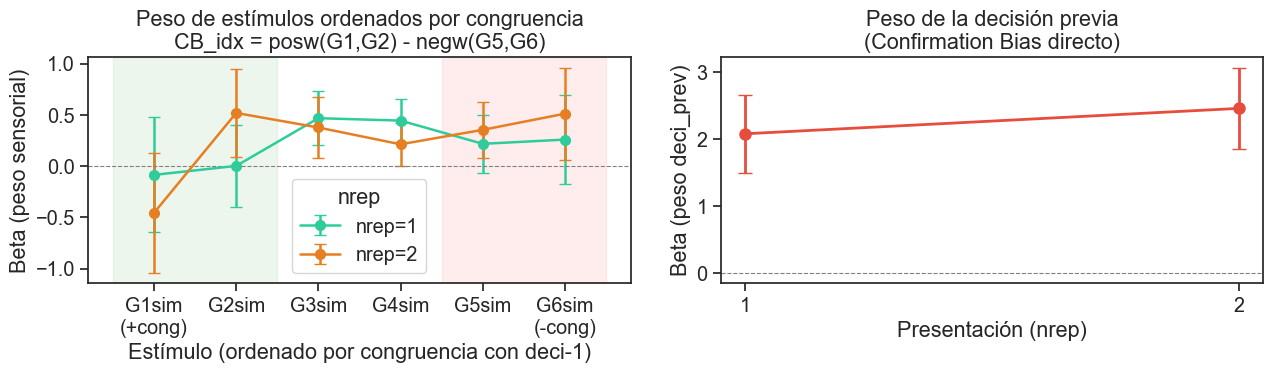

In [18]:
# ── Celda 18: Plot CB Index ─────────────────────────────────────────────────
df_sim = df_coefs_sim[df_coefs_sim["term"].isin(sim_names)].copy()
df_dp  = df_coefs_sim[df_coefs_sim["term"] == "deci_prev"].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

palette = {1: "#2ecc9a", 2: "#e67e22"}
for nrep_val, color in palette.items():
    d = df_sim[df_sim["nrep"] == nrep_val]
    axes[0].errorbar(
        x=range(6), y=d["estimate"],
        yerr=[d["estimate"] - d["conf_low"], d["conf_high"] - d["estimate"]],
        fmt="o-", color=color, capsize=4, label=f"nrep={nrep_val}",
        linewidth=1.8, markersize=7
    )
axes[0].axhline(0, color="gray", linestyle="--", linewidth=0.8)
axes[0].set_xticks(range(6))
axes[0].set_xticklabels(["G1sim\n(+cong)","G2sim","G3sim","G4sim","G5sim","G6sim\n(-cong)"])
axes[0].set_xlabel("Estímulo (ordenado por congruencia con deci-1)")
axes[0].set_ylabel("Beta (peso sensorial)")
axes[0].set_title("Peso de estímulos ordenados por congruencia\nCB_idx = posw(G1,G2) - negw(G5,G6)")
axes[0].legend(title="nrep")
axes[0].axvspan(-0.5, 1.5, alpha=0.07, color="green")
axes[0].axvspan(3.5, 5.5, alpha=0.07, color="red")

axes[1].errorbar(
    x=[0, 1], y=df_dp["estimate"],
    yerr=[df_dp["estimate"] - df_dp["conf_low"],
          df_dp["conf_high"] - df_dp["estimate"]],
    fmt="o-", color="#e74c3c", capsize=5, linewidth=2, markersize=8
)
axes[1].axhline(0, color="gray", linestyle="--", linewidth=0.8)
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["1", "2"])
axes[1].set_xlabel("Presentación (nrep)")
axes[1].set_ylabel("Beta (peso deci_prev)")
axes[1].set_title("Peso de la decisión previa\n(Confirmation Bias directo)")
plt.tight_layout()
plt.show()

In [19]:
# ── Celda 19: GLMM Stubbornness ─────────────────────────────────────────────
# Solo trials donde correct-1 == 0 (error previo)
# Modelo: switch ~ nrep * is_repeat + (1|subj)

df_err = df_rep[df_rep["correct-1"] == 0].copy()

print(f"Trials con error previo  : {len(df_err)}")
print(f"Stubbornness media global: {(1 - df_err['switch'].mean()):.3f}")
print()
print("Stubbornness por condición (p(no cambiar | error previo)):")
print(df_err.groupby(["nrep","trial_type"])["switch"].apply(
    lambda x: (1 - x.mean())).round(3))

md_stub = glmer(
    "switch ~ nrep * is_repeat + (1|subj)",
    data=pl.from_pandas(df_err),
    family="binomial"
)
md_stub.fit()

coefs_stub    = md_stub.result_fit
coefs_stub_pd = coefs_stub.to_pandas()
print(coefs_stub)

intercept_stub = coefs_stub_pd.loc[coefs_stub_pd["term"]=="(Intercept)", "estimate"].values[0]
p_stub = 1 / (1 + np.exp(-intercept_stub))
print(f"\np(NO cambiar | error previo): {1-p_stub:.3f}")
print(f"→ Los participantes mantienen su decisión errónea el {(1-p_stub)*100:.1f}% de las veces")

Trials con error previo  : 1208
Stubbornness media global: 0.728

Stubbornness por condición (p(no cambiar | error previo)):
nrep  trial_type
1     nonrepeat     0.687
      repeat        0.746
2     nonrepeat     0.704
      repeat        0.771
Name: switch, dtype: float64
shape: (4, 8)
┌────────────────┬───────────┬───────────┬───────────┬───────────┬───────────┬─────┬──────────┐
│ term           ┆ estimate  ┆ std_error ┆ conf_low  ┆ conf_high ┆ z_stat    ┆ df  ┆ p_value  │
│ ---            ┆ ---       ┆ ---       ┆ ---       ┆ ---       ┆ ---       ┆ --- ┆ ---      │
│ str            ┆ f64       ┆ f64       ┆ f64       ┆ f64       ┆ f64       ┆ f64 ┆ f64      │
╞════════════════╪═══════════╪═══════════╪═══════════╪═══════════╪═══════════╪═════╪══════════╡
│ (Intercept)    ┆ -0.745508 ┆ 0.30764   ┆ -1.348471 ┆ -0.142545 ┆ -2.423313 ┆ inf ┆ 0.01538  │
│ nrep           ┆ -0.082391 ┆ 0.184507  ┆ -0.444018 ┆ 0.279235  ┆ -0.446548 ┆ inf ┆ 0.655201 │
│ is_repeat      ┆ -0.261423 ┆ 0.415387

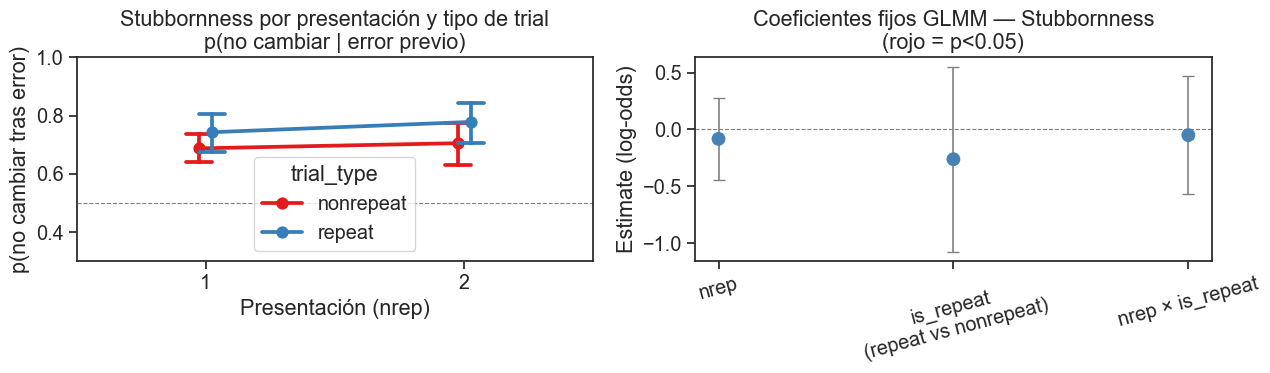


Interpretación:
  nrep                      β=-0.0824  p=0.6552  → n.s.
  is_repeat                 β=-0.2614  p=0.5291  → n.s.
  nrep:is_repeat            β=-0.0494  p=0.8529  → n.s.


In [20]:
# ── Celda 20: Plot Stubbornness ─────────────────────────────────────────────
avg_stub = df_err.groupby(["subj","nrep","trial_type"], as_index=False)["switch"].mean()
avg_stub["stubbornness"] = 1 - avg_stub["switch"]

coefs_st_plot = coefs_stub_pd[coefs_stub_pd["term"] != "(Intercept)"].copy()
colors_st     = ["#e74c3c" if p < 0.05 else "steelblue" for p in coefs_st_plot["p_value"]]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.pointplot(data=avg_stub, x="nrep", y="stubbornness", hue="trial_type",
              dodge=True, capsize=0.1, palette="Set1", ax=axes[0])
axes[0].axhline(0.5, color="gray", linestyle="--", linewidth=0.8, label="azar")
axes[0].set_title("Stubbornness por presentación y tipo de trial\np(no cambiar | error previo)")
axes[0].set_xlabel("Presentación (nrep)")
axes[0].set_ylabel("p(no cambiar tras error)")
axes[0].set_ylim(0.3, 1.0)

axes[1].axhline(0, color="gray", linestyle="--", linewidth=0.8)
axes[1].errorbar(
    x=range(len(coefs_st_plot)),
    y=coefs_st_plot["estimate"],
    yerr=[coefs_st_plot["estimate"] - coefs_st_plot["conf_low"],
          coefs_st_plot["conf_high"] - coefs_st_plot["estimate"]],
    fmt="none", color="gray", capsize=4, linewidth=1.2, zorder=1
)
axes[1].scatter(range(len(coefs_st_plot)), coefs_st_plot["estimate"],
                color=colors_st, s=80, zorder=2)
axes[1].set_xticks(range(len(coefs_st_plot)))
axes[1].set_xticklabels(
    ["nrep", "is_repeat\n(repeat vs nonrepeat)", "nrep × is_repeat"],
    rotation=15)
axes[1].set_ylabel("Estimate (log-odds)")
axes[1].set_title("Coeficientes fijos GLMM — Stubbornness\n(rojo = p<0.05)")
plt.tight_layout()
plt.show()

print("\nInterpretación:")
for _, row in coefs_st_plot.iterrows():
    sig = "✓ SIGNIFICATIVO" if row["p_value"] < 0.05 else "n.s."
    print(f"  {row['term']:25s} β={row['estimate']:+.4f}  p={row['p_value']:.4f}  → {sig}")

In [38]:
# ── Celda 21: GLMM Metacognición global ─────────────────────────────────────
# Cambios respecto a la versión anterior:
# - Se sustituye rDV_z por nrep como predictor
# - Se sustituye metad_z por metad_efficiency
# Modelo: correct ~ nrep * metad_eff + correct_prev + (1|subj)

# Calcular metad_efficiency por participante
df0 = df_rt[df_rt["nrep"] == 0].copy()

def calc_dprime(x):
    hits   = ((x["deci"] == 1) & (x["cond"] == 1)).sum()
    signal = (x["cond"] == 1).sum()
    fa     = ((x["deci"] == 1) & (x["cond"] == 0)).sum()
    noise  = (x["cond"] == 0).sum()
    hr  = (hits + 0.5) / (signal + 1)
    far = (fa   + 0.5) / (noise  + 1)
    return pd.Series({"dprime": norm.ppf(hr) - norm.ppf(far)})

dprime_df  = df0.groupby("subj").apply(calc_dprime, include_groups=False).reset_index()
metad_subj = df_rt.groupby("subj")["metad"].first().reset_index()
eff_df     = metad_subj.merge(dprime_df, on="subj")
eff_df["metad_eff"] = eff_df["metad"] / eff_df["dprime"]

# Preparar dataframe
df_meta = df_rt[df_rt["nrep"] > 0].copy()
df_meta = df_meta.rename(columns={"correct-1": "correct_prev"})
df_meta["correct_prev"] = df_meta["correct_prev"].astype(float)
df_meta = df_meta.merge(eff_df[["subj", "metad_eff"]], on="subj")
df_meta["metad_eff_z"] = (df_meta["metad_eff"] - df_meta["metad_eff"].mean()) / df_meta["metad_eff"].std()
df_meta = df_meta.dropna(subset=["correct", "correct_prev", "metad_eff_z"]).reset_index(drop=True)

print(f"Trials: {len(df_meta)} | Participantes: {df_meta['subj'].nunique()}")

md_metad = glmer(
    "correct ~ nrep * metad_eff_z + correct_prev + (1|subj)",
    data=pl.from_pandas(df_meta),
    family="binomial"
)
md_metad.fit()

coefs_metad    = md_metad.result_fit
coefs_metad_pd = coefs_metad.to_pandas()
print(coefs_metad)

print("\nInterpretación:")
for _, row in coefs_metad_pd.iterrows():
    sig = "✓ SIGNIFICATIVO" if row["p_value"] < 0.05 else "n.s."
    print(f"  {row['term']:30s} β={row['estimate']:+.4f}  p={row['p_value']:.4f}  → {sig}")

Trials: 4195 | Participantes: 24
shape: (5, 8)
┌──────────────────┬───────────┬───────────┬───────────┬───────────┬───────────┬─────┬─────────────┐
│ term             ┆ estimate  ┆ std_error ┆ conf_low  ┆ conf_high ┆ z_stat    ┆ df  ┆ p_value     │
│ ---              ┆ ---       ┆ ---       ┆ ---       ┆ ---       ┆ ---       ┆ --- ┆ ---         │
│ str              ┆ f64       ┆ f64       ┆ f64       ┆ f64       ┆ f64       ┆ f64 ┆ f64         │
╞══════════════════╪═══════════╪═══════════╪═══════════╪═══════════╪═══════════╪═════╪═════════════╡
│ (Intercept)      ┆ -0.994264 ┆ 0.152329  ┆ -1.292822 ┆ -0.695705 ┆ -6.527099 ┆ inf ┆ 6.7056e-11  │
│ nrep             ┆ 0.007811  ┆ 0.090589  ┆ -0.169739 ┆ 0.185362  ┆ 0.086229  ┆ inf ┆ 0.931285    │
│ metad_eff_z      ┆ 0.233873  ┆ 0.145479  ┆ -0.05126  ┆ 0.519007  ┆ 1.607608  ┆ inf ┆ 0.107921    │
│ correct_prev     ┆ 3.252261  ┆ 0.091093  ┆ 3.073722  ┆ 3.430801  ┆ 35.702541 ┆ inf ┆ 3.6101e-279 │
│ nrep:metad_eff_z ┆ -0.126744 ┆ 0.090617  ┆

/var/folders/6t/135j38t15hx5h_82vyspq6pm0000gn/T/ipykernel_95728/1423428399.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_meta_global = df_meta.groupby(


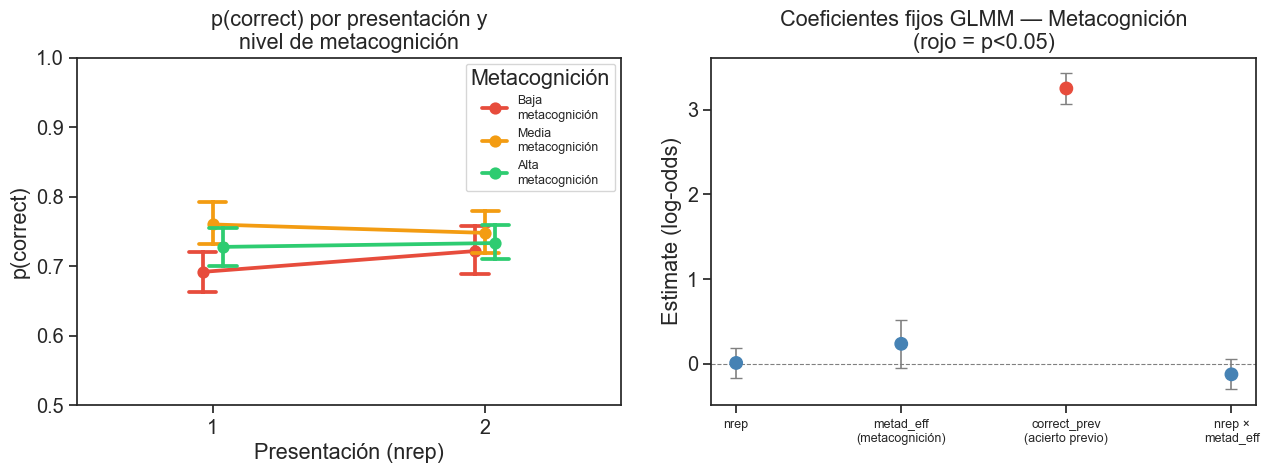

In [39]:
# ── Celda 21b: Plot Metacognición global ─────────────────────────────────────
# p(correct) en función de nrep, separando por nivel de metad_efficiency

# Dividir metad_eff en 3 niveles por terciles
df_meta["metad_eff_bin"] = pd.qcut(
    df_meta["metad_eff_z"], q=3,
    labels=["Baja\nmetacognición", "Media\nmetacognición", "Alta\nmetacognición"]
)

avg_meta_global = df_meta.groupby(
    ["subj", "nrep", "metad_eff_bin"], as_index=False
)["correct"].mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Izquierda: p(correct) por nrep y nivel de metacognición
sns.pointplot(
    data=avg_meta_global, x="nrep", y="correct",
    hue="metad_eff_bin", dodge=True, capsize=0.1,
    palette={"Baja\nmetacognición": "#e74c3c",
             "Media\nmetacognición": "#f39c12",
             "Alta\nmetacognición": "#2ecc71"},
    ax=axes[0]
)
axes[0].axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
axes[0].set_title("p(correct) por presentación y\nnivel de metacognición")
axes[0].set_xlabel("Presentación (nrep)")
axes[0].set_ylabel("p(correct)")
axes[0].set_ylim(0.5, 1.0)
axes[0].legend(title="Metacognición", fontsize=9)

# Derecha: coeficientes del modelo
coefs_plot = coefs_metad_pd[coefs_metad_pd["term"] != "(Intercept)"].copy()
colors_m   = ["#e74c3c" if p < 0.05 else "steelblue" for p in coefs_plot["p_value"]]

axes[1].axhline(0, color="gray", linestyle="--", linewidth=0.8)
axes[1].errorbar(
    x=range(len(coefs_plot)),
    y=coefs_plot["estimate"],
    yerr=[coefs_plot["estimate"] - coefs_plot["conf_low"],
          coefs_plot["conf_high"] - coefs_plot["estimate"]],
    fmt="none", color="gray", capsize=4, linewidth=1.2, zorder=1
)
axes[1].scatter(range(len(coefs_plot)), coefs_plot["estimate"],
                color=colors_m, s=80, zorder=2)
axes[1].set_xticks(range(len(coefs_plot)))
axes[1].set_xticklabels(
    ["nrep", "metad_eff\n(metacognición)", "correct_prev\n(acierto previo)", "nrep ×\nmetad_eff"],
    fontsize=9)
axes[1].set_ylabel("Estimate (log-odds)")
axes[1].set_title("Coeficientes fijos GLMM — Metacognición\n(rojo = p<0.05)")

plt.tight_layout()
plt.show()

In [42]:
# ── Celda 22: GLMM Metacognición trial a trial ──────────────────────────────
# Modelo: deci ~ rDV_z + deci1_c * confi1_z * correct_prev + (1|subj)
# Pregunta: ¿confianza previa amplifica el sesgo de confirmación?

# Usamos df_rep_meta filtrado a nrep > 0 para no depender de cómo esté definido df_rep
df_rep_meta = df_rt[df_rt["nrep"] > 0].dropna(
    subset=["deci1_c", "rDV_z", "is_repeat"]
).copy()

df_rep_meta["confi-1"] = df_rep_meta.groupby(
    ["subj", "nblock", "ntrial"]
)["confi"].shift(1)

df_meta_trial = df_rep_meta.dropna(subset=["confi-1"]).copy()
df_meta_trial["confi1_z"] = df_meta_trial.groupby("subj")["confi-1"].transform(
    lambda x: (x - x.mean()) / x.std())
df_meta_trial["correct_prev"] = df_meta_trial["correct-1"].astype(float)

print(f"Trials: {len(df_meta_trial)} | Participantes: {df_meta_trial['subj'].nunique()}")

md_meta_trial = glmer(
    "deci ~ rDV_z + deci1_c * confi1_z * correct_prev + (1|subj)",
    data=pl.from_pandas(df_meta_trial),
    family="binomial"
)
md_meta_trial.fit()

coefs_mt    = md_meta_trial.result_fit
coefs_mt_pd = coefs_mt.to_pandas()
print(coefs_mt)

print("\nEfectos significativos:")
for _, row in coefs_mt_pd.iterrows():
    sig = "✓ SIGNIFICATIVO" if row["p_value"] < 0.05 else "n.s."
    print(f"  {row['term']:35s} β={row['estimate']:+.4f}  p={row['p_value']:.4f}  → {sig}")

Trials: 2170 | Participantes: 25
shape: (9, 8)
┌───────────────────┬───────────┬───────────┬───────────┬───────────┬───────────┬─────┬────────────┐
│ term              ┆ estimate  ┆ std_error ┆ conf_low  ┆ conf_high ┆ z_stat    ┆ df  ┆ p_value    │
│ ---               ┆ ---       ┆ ---       ┆ ---       ┆ ---       ┆ ---       ┆ --- ┆ ---        │
│ str               ┆ f64       ┆ f64       ┆ f64       ┆ f64       ┆ f64       ┆ f64 ┆ f64        │
╞═══════════════════╪═══════════╪═══════════╪═══════════╪═══════════╪═══════════╪═════╪════════════╡
│ (Intercept)       ┆ 0.186456  ┆ 0.146431  ┆ -0.100543 ┆ 0.473456  ┆ 1.273341  ┆ inf ┆ 0.202897   │
│ rDV_z             ┆ 0.920719  ┆ 0.150526  ┆ 0.625694  ┆ 1.215744  ┆ 6.116686  ┆ inf ┆ 9.5541e-10 │
│ deci1_c           ┆ 3.48546   ┆ 0.313407  ┆ 2.871193  ┆ 4.099726  ┆ 11.12119  ┆ inf ┆ 9.8943e-29 │
│ confi1_z          ┆ 0.030666  ┆ 0.117136  ┆ -0.198917 ┆ 0.260249  ┆ 0.261798  ┆ inf ┆ 0.793477   │
│ correct_prev      ┆ 0.124841  ┆ 0.156244  

/var/folders/6t/135j38t15hx5h_82vyspq6pm0000gn/T/ipykernel_95728/216808587.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_meta = df_meta_trial.groupby(


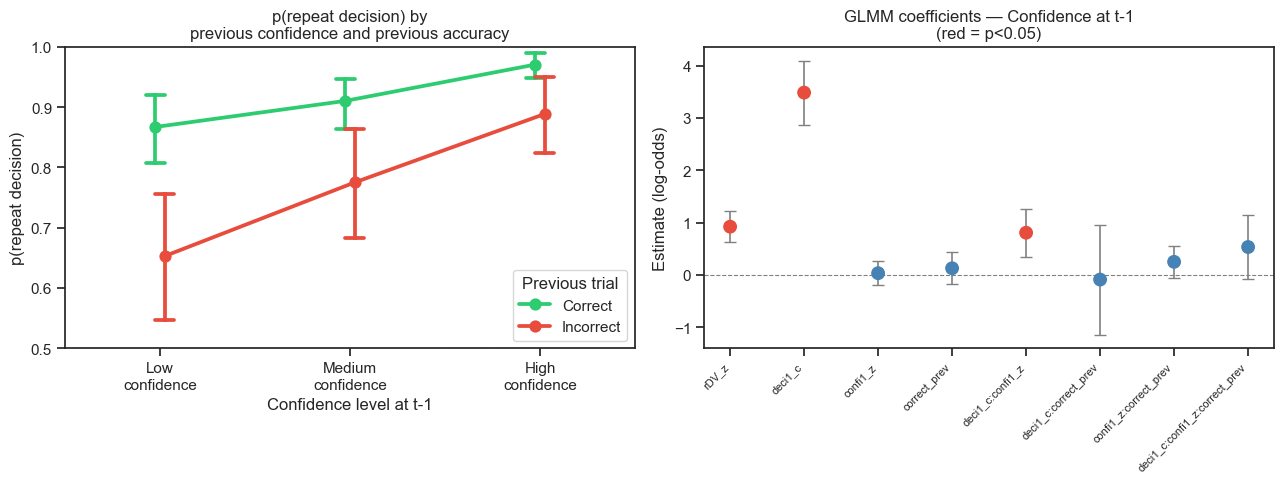

In [76]:
# ── Cell 23: Plot Trial-by-trial Metacognition ────────────────────────────────
df_meta_trial["confi1_bin"] = pd.qcut(
    df_meta_trial["confi-1"], q=3,
    labels=["Low\nconfidence", "Medium\nconfidence", "High\nconfidence"])
df_meta_trial["p_repeat"]  = 1 - df_meta_trial["switch"]
df_meta_trial["prev_label"] = df_meta_trial["correct_prev"].map(
    {1.0: "Correct", 0.0: "Incorrect"})
avg_meta = df_meta_trial.groupby(
    ["subj", "confi1_bin", "prev_label"], as_index=False
)["p_repeat"].mean()
coefs_mt_plot = coefs_mt_pd[coefs_mt_pd["term"] != "(Intercept)"].copy()
colors_mt     = ["#e74c3c" if p < 0.05 else "steelblue" for p in coefs_mt_plot["p_value"]]
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.pointplot(
    data=avg_meta, x="confi1_bin", y="p_repeat",
    hue="prev_label", dodge=True, capsize=0.1,
    palette={"Correct": "#2ecc71", "Incorrect": "#e74c3c"},
    ax=axes[0]
)
axes[0].axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
axes[0].set_title("p(repeat decision) by\nprevious confidence and previous accuracy")
axes[0].set_xlabel("Confidence level at t-1")
axes[0].set_ylabel("p(repeat decision)")
axes[0].set_ylim(0.5, 1.0)
axes[0].legend(title="Previous trial")
axes[1].axhline(0, color="gray", linestyle="--", linewidth=0.8)
axes[1].errorbar(
    x=range(len(coefs_mt_plot)),
    y=coefs_mt_plot["estimate"],
    yerr=[coefs_mt_plot["estimate"] - coefs_mt_plot["conf_low"],
          coefs_mt_plot["conf_high"] - coefs_mt_plot["estimate"]],
    fmt="none", color="gray", capsize=4, linewidth=1.2, zorder=1
)
axes[1].scatter(range(len(coefs_mt_plot)), coefs_mt_plot["estimate"],
                color=colors_mt, s=80, zorder=2)
axes[1].set_xticks(range(len(coefs_mt_plot)))
axes[1].set_xticklabels(coefs_mt_plot["term"], rotation=45, ha="right", fontsize=8)
axes[1].set_ylabel("Estimate (log-odds)")
axes[1].set_title("GLMM coefficients — Confidence at t-1\n(red = p<0.05)")
plt.tight_layout()
plt.show()

Correct: β=-0.0740  p=0.3846
Incorrect: β=+0.0919  p=0.3501


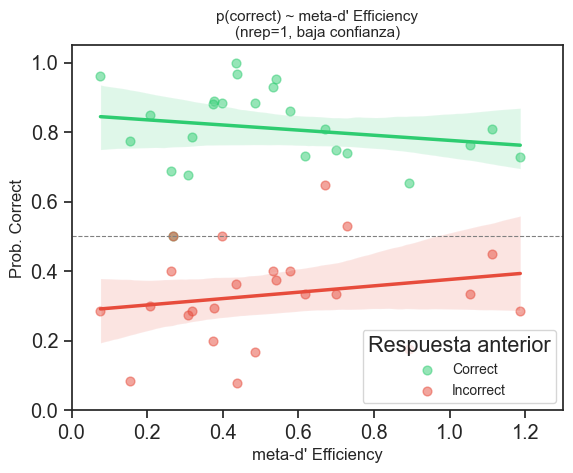

In [46]:
# ── Celda 24: meta-d' Efficiency — baja confianza ───────────────────────────
# Análisis complementario del tutor:
# p(correct) ~ metad_efficiency por resultado previo
# Solo nrep=1, baja confianza (< mediana por participante)

df0 = df_rt[df_rt["nrep"] == 0].copy()

def calc_dprime(x):
    hits   = ((x["deci"] == 1) & (x["cond"] == 1)).sum()
    signal = (x["cond"] == 1).sum()
    fa     = ((x["deci"] == 1) & (x["cond"] == 0)).sum()
    noise  = (x["cond"] == 0).sum()
    hr  = (hits + 0.5) / (signal + 1)
    far = (fa   + 0.5) / (noise  + 1)
    return pd.Series({"dprime": norm.ppf(hr) - norm.ppf(far)})

dprime_df  = df0.groupby("subj").apply(calc_dprime, include_groups=False).reset_index()
metad_subj = df_rt.groupby("subj")["metad"].first().reset_index()
eff_df     = metad_subj.merge(dprime_df, on="subj")
eff_df["metad_eff"] = eff_df["metad"] / eff_df["dprime"]

df_p1 = df_rt[df_rt["nrep"] == 1].copy()
df_p1["correct_prev"] = df_p1["correct-1"].astype(float)
df_p1 = df_p1.dropna(subset=["correct","correct_prev","metad"]).reset_index(drop=True)
df_p1 = df_p1.merge(eff_df[["subj","metad_eff"]], on="subj")

median_confi = df_p1.groupby("subj")["confi"].transform("median")
df_p1_low    = df_p1[df_p1["confi"] < median_confi].copy()

by_subj_p1 = df_p1_low.groupby(
    ["subj","correct_prev","metad_eff"], as_index=False
)["correct"].mean()
by_subj_p1["label"] = by_subj_p1["correct_prev"].map(
    {1.0: "Correct", 0.0: "Incorrect"})

fig, ax = plt.subplots(figsize=(6, 5))
colors = {"Correct": "#2ecc71", "Incorrect": "#e74c3c"}

for label, color in colors.items():
    d = by_subj_p1[by_subj_p1["label"] == label]
    sns.regplot(data=d, x="metad_eff", y="correct",
                color=color, scatter=True, ci=95, n_boot=1000, label=label,
                scatter_kws={"alpha": 0.5, "s": 40},
                line_kws={"linewidth": 2.5}, ax=ax)
    slope, intercept, r, p, se = stats.linregress(d["metad_eff"], d["correct"])
    print(f"{label}: β={slope:+.4f}  p={p:.4f}")

ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
ax.set_xlabel("meta-d' Efficiency", fontsize=12)
ax.set_ylabel("Prob. Correct", fontsize=12)
ax.set_title("p(correct) ~ meta-d' Efficiency\n(nrep=1, baja confianza)", fontsize=11)
ax.legend(title="Respuesta anterior", fontsize=10)
ax.set_ylim(0.0, 1.05)
ax.set_xlim(0.0, 1.3)
plt.tight_layout()
plt.show()

Previous response: Correct | nrep=0: β=-0.2213  p=0.0000
Previous response: Correct | nrep=1: β=-0.0740  p=0.3846
Previous response: Correct | nrep=2: β=+0.0208  p=0.8369
Previous response: Incorrect | nrep=0: β=-0.2213  p=0.0000
Previous response: Incorrect | nrep=1: β=+0.0919  p=0.3501
Previous response: Incorrect | nrep=2: β=-0.1570  p=0.2552


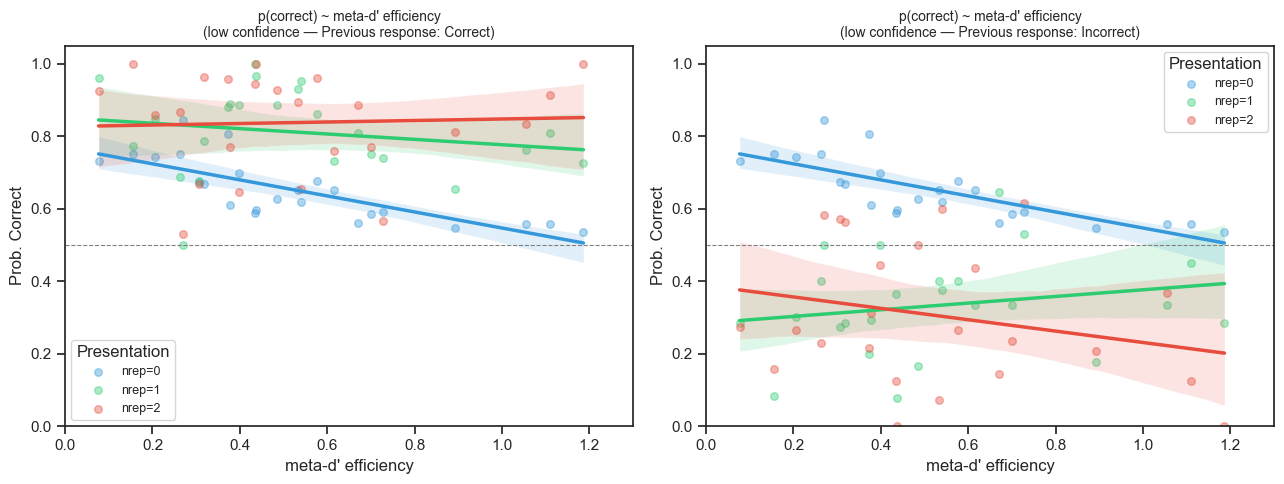

In [69]:
# ── Cell 24b: meta-d' Efficiency — low confidence, all nrep ───────────
# Same logic as cell 24 but with all nrep overlaid (one line per nrep)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
palette_nrep = {0: "#3498db", 1: "#2ecc71", 2: "#e74c3c"}
labels_nrep  = {0: "nrep=0", 1: "nrep=1", 2: "nrep=2"}
for correct_val, ax, title in zip(
    [1.0, 0.0], axes,
    ["Previous response: Correct", "Previous response: Incorrect"]
):
    for nrep_val, color in palette_nrep.items():
        df_nrep = df_rt[df_rt["nrep"] == nrep_val].copy()
        df_nrep["correct_prev"] = df_nrep["correct-1"].astype(float)
        df_nrep = df_nrep.dropna(subset=["correct", "correct_prev", "metad"]).reset_index(drop=True)
        df_nrep = df_nrep.merge(eff_df[["subj", "metad_eff"]], on="subj")
        # Filter low confidence
        median_confi = df_nrep.groupby("subj")["confi"].transform("median")
        df_nrep_low  = df_nrep[df_nrep["confi"] < median_confi].copy()
        # Filter by correct_prev (except nrep=0 which has no correct_prev)
        if nrep_val == 0:
            df_plot = df_nrep_low.copy()
        else:
            df_plot = df_nrep_low[df_nrep_low["correct_prev"] == correct_val].copy()
        by_subj = df_plot.groupby(
            ["subj", "metad_eff"], as_index=False
        )["correct"].mean()
        if len(by_subj) < 3:
            continue
        sns.regplot(
            data=by_subj, x="metad_eff", y="correct",
            color=color, scatter=True, ci=95, n_boot=1000,
            label=labels_nrep[nrep_val],
            scatter_kws={"alpha": 0.4, "s": 30},
            line_kws={"linewidth": 2.5}, ax=ax
        )
        slope, intercept, r, p, se = stats.linregress(by_subj["metad_eff"], by_subj["correct"])
        print(f"{title} | {labels_nrep[nrep_val]}: β={slope:+.4f}  p={p:.4f}")
    ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
    ax.set_xlabel("meta-d' efficiency", fontsize=12)
    ax.set_ylabel("Prob. Correct", fontsize=12)
    ax.set_title(f"p(correct) ~ meta-d' efficiency\n(low confidence — {title})", fontsize=10)
    ax.legend(title="Presentation", fontsize=9)
    ax.set_ylim(0.0, 1.05)
    ax.set_xlim(0.0, 1.3)
plt.tight_layout()
plt.show()

Respuesta anterior: Correcta | nrep=0: β=+0.1327  p=0.0013
Respuesta anterior: Correcta | nrep=1: β=+0.0474  p=0.1527
Respuesta anterior: Correcta | nrep=2: β=+0.0564  p=0.0418
Respuesta anterior: Incorrecta | nrep=0: β=+0.1327  p=0.0013
Respuesta anterior: Incorrecta | nrep=1: β=+0.0569  p=0.6218
Respuesta anterior: Incorrecta | nrep=2: β=-0.1623  p=0.1424


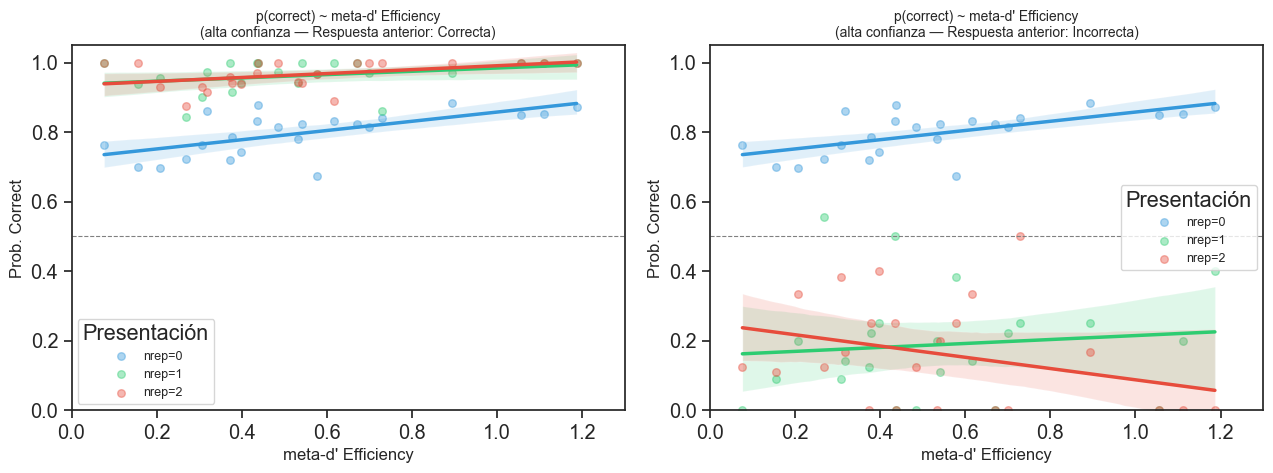

In [48]:
# ── Celda 24c: meta-d' Efficiency — ALTA confianza, todas las nrep ───────────
# Misma lógica que celda 24b pero con alta confianza (> mediana por participante)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

palette_nrep = {0: "#3498db", 1: "#2ecc71", 2: "#e74c3c"}
labels_nrep  = {0: "nrep=0", 1: "nrep=1", 2: "nrep=2"}

for correct_val, ax, title in zip(
    [1.0, 0.0], axes,
    ["Respuesta anterior: Correcta", "Respuesta anterior: Incorrecta"]
):
    for nrep_val, color in palette_nrep.items():
        df_nrep = df_rt[df_rt["nrep"] == nrep_val].copy()
        df_nrep["correct_prev"] = df_nrep["correct-1"].astype(float)
        df_nrep = df_nrep.dropna(subset=["correct", "correct_prev", "metad"]).reset_index(drop=True)
        df_nrep = df_nrep.merge(eff_df[["subj", "metad_eff"]], on="subj")

        # Filtrar ALTA confianza (> mediana) — único cambio respecto a celda 24b
        median_confi = df_nrep.groupby("subj")["confi"].transform("median")
        df_nrep_high = df_nrep[df_nrep["confi"] > median_confi].copy()

        # Filtrar por correct_prev (excepto nrep=0 que no tiene correct_prev)
        if nrep_val == 0:
            df_plot = df_nrep_high.copy()
        else:
            df_plot = df_nrep_high[df_nrep_high["correct_prev"] == correct_val].copy()

        by_subj = df_plot.groupby(
            ["subj", "metad_eff"], as_index=False
        )["correct"].mean()

        if len(by_subj) < 3:
            continue

        sns.regplot(
            data=by_subj, x="metad_eff", y="correct",
            color=color, scatter=True, ci=95, n_boot=1000,
            label=labels_nrep[nrep_val],
            scatter_kws={"alpha": 0.4, "s": 30},
            line_kws={"linewidth": 2.5}, ax=ax
        )

        slope, intercept, r, p, se = stats.linregress(by_subj["metad_eff"], by_subj["correct"])
        print(f"{title} | {labels_nrep[nrep_val]}: β={slope:+.4f}  p={p:.4f}")

    ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
    ax.set_xlabel("meta-d' Efficiency", fontsize=12)
    ax.set_ylabel("Prob. Correct", fontsize=12)
    ax.set_title(f"p(correct) ~ meta-d' Efficiency\n(alta confianza — {title})", fontsize=10)
    ax.legend(title="Presentación", fontsize=9)
    ax.set_ylim(0.0, 1.05)
    ax.set_xlim(0.0, 1.3)

plt.tight_layout()
plt.show()

In [53]:
# ── Celda 25: SDT por participante y nrep (d' y criterio) ───────────────────
# Base para Paneles C y D de la figura
# d' = sensibilidad perceptual
# criterio (c) = sesgo de respuesta

def calc_sdt(x):
    hits = ((x['deci'] == 1) & (x['cond'] == 1)).sum()
    sig  = (x['cond'] == 1).sum()
    fa   = ((x['deci'] == 1) & (x['cond'] == 0)).sum()
    noi  = (x['cond'] == 0).sum()
    hr   = (hits + 0.5) / (sig + 1)   # correccion Hautus
    far  = (fa   + 0.5) / (noi + 1)
    dp   = norm.ppf(hr) - norm.ppf(far)
    crit = -0.5 * (norm.ppf(hr) + norm.ppf(far))
    return pd.Series({'dprime': dp, 'criterion': crit})

sdt_df  = df_rt.groupby(['subj', 'nrep']).apply(calc_sdt, include_groups=False).reset_index()
sdt_avg = sdt_df.groupby('nrep')[['dprime', 'criterion']].agg(['mean', 'sem']).reset_index()
sdt_avg.columns = ['nrep', 'dp_mean', 'dp_sem', 'crit_mean', 'crit_sem']

print("d' y criterio por presentacion:")
print(sdt_avg.round(3))

d' y criterio por presentacion:
   nrep  dp_mean  dp_sem  crit_mean  crit_sem
0     0    1.233   0.034     -0.226     0.062
1     1    1.274   0.062     -0.201     0.066
2     2    1.339   0.053     -0.189     0.076


In [77]:
# ── Celda 26 corregida v2: menos bins para suavizar ─────────────────────────

n_bins = 5   # bajamos de 8 a 6 para suavizar
df_rt['rDV_bin'] = pd.qcut(df_rt['rDV'], q=n_bins, labels=False, duplicates='drop')

psy_data = df_rt.groupby(['subj', 'nrep', 'deci-1', 'rDV_bin'], as_index=False).agg(
    p_deci   = ('deci',  'mean'),
    rDV_mean = ('rDV', 'mean')
)

psy_avg = psy_data.groupby(['nrep', 'deci-1', 'rDV_bin'], as_index=False).agg(
    p_deci     = ('p_deci',  'mean'),
    rDV_mean   = ('rDV_mean','mean'),
    p_deci_sem = ('p_deci',  'sem')
)

psy_avg_nrep = psy_data.groupby(['nrep', 'rDV_bin'], as_index=False).agg(
    p_deci     = ('p_deci',  'mean'),
    rDV_mean   = ('rDV_mean','mean'),
    p_deci_sem = ('p_deci',  'sem')
)

print('Curvas psicometricas calculadas')
print(f'  nrep disponibles  : {sorted(psy_avg["nrep"].unique())}')
print(f'  deci-1 disponibles: {sorted(psy_avg["deci-1"].unique())}')

Curvas psicometricas calculadas
  nrep disponibles  : [np.int64(0), np.int64(1), np.int64(2)]
  deci-1 disponibles: [np.int64(0), np.int64(1)]


In [78]:
# ── Celda 27: GLMM por nrep × deci-1 → Intercept y Slope ───────────────────
# Base para Paneles E (intercept = sesgo de respuesta) e I (slope = sensibilidad)
# Ajustamos un modelo separado por cada combinacion nrep x deci-1

results_by_nrep = []

for nrep_val in [1, 2]:
    dat = df_rep[df_rep['nrep'] == nrep_val].copy()
    for deci_val in [0, 1]:
        dat_d = dat[dat['deci-1'] == deci_val].copy()
        try:
            md = glmer(
                'deci ~ rDV_z + (1|subj)',
                data=pl.from_pandas(dat_d),
                family='binomial'
            )
            md.fit()
            c = md.result_fit.to_pandas()

            intercept    = c.loc[c['term'] == '(Intercept)', 'estimate'].values[0]
            intercept_lo = c.loc[c['term'] == '(Intercept)', 'conf_low'].values[0]
            intercept_hi = c.loc[c['term'] == '(Intercept)', 'conf_high'].values[0]
            slope        = c.loc[c['term'] == 'rDV_z', 'estimate'].values[0]
            slope_lo     = c.loc[c['term'] == 'rDV_z', 'conf_low'].values[0]
            slope_hi     = c.loc[c['term'] == 'rDV_z', 'conf_high'].values[0]

            results_by_nrep.append({
                'nrep': nrep_val, 'deci_prev': deci_val,
                'intercept': intercept, 'int_lo': intercept_lo, 'int_hi': intercept_hi,
                'slope': slope, 'slope_lo': slope_lo, 'slope_hi': slope_hi
            })
        except Exception as e:
            print(f'Error nrep={nrep_val}, deci={deci_val}: {e}')

params_df = pd.DataFrame(results_by_nrep)
params_df['deci_label']  = params_df['deci_prev'].map({0: '(n-1) C', 1: '(n-1) D'})
params_df['nrep_label']  = params_df['nrep'].map({1: 'P2', 2: 'P3'})

print('Intercept y Slope por nrep x deci-1:')
print(params_df[['nrep_label','deci_label','intercept','slope']].round(3).to_string(index=False))

Intercept y Slope por nrep x deci-1:
nrep_label deci_label  intercept  slope
        P2    (n-1) C     -1.324  1.022
        P2    (n-1) D      1.719  0.984
        P3    (n-1) C     -1.502  1.085
        P3    (n-1) D      2.002  1.070


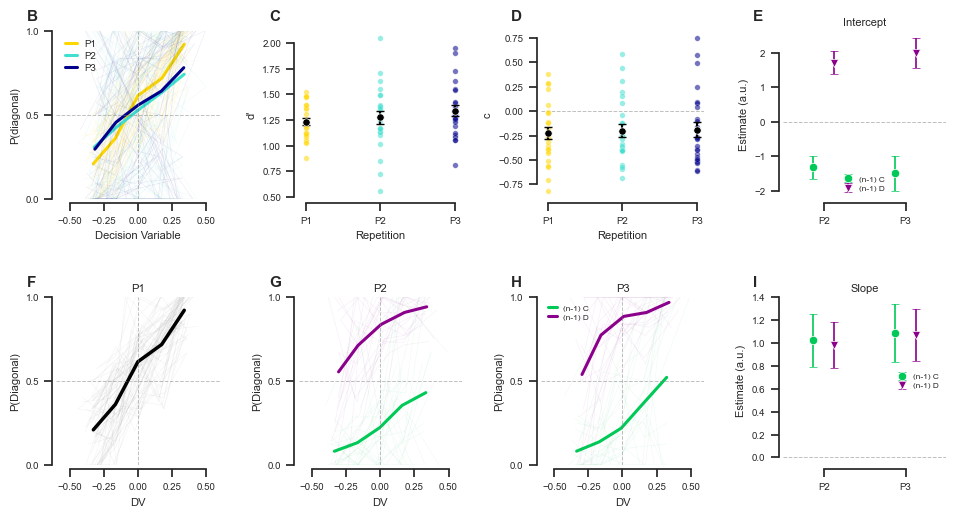

Figure saved: Figure1_Behavioural.png / .svg


In [79]:
# ── Celda 28 corregida v4: Figura completa — Paneles B a I ──────────────────

import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D

sns.set(font_scale=1.0, style='ticks')

COLPAL2      = ['#FFD700', '#40E0D0', '#00008B']
COLPAL3      = ['#00C957', '#8B008B']
nrep_colors  = {0: COLPAL2[0], 1: COLPAL2[1], 2: COLPAL2[2]}
deci_colors  = {0: COLPAL3[0], 1: COLPAL3[1]}
deci_markers = {0: 'o', 1: 'v'}
deci_labels  = {0: '(n-1) C', 1: '(n-1) D'}
x_pos        = {'P2': 0, 'P3': 1}

LBL = 8; TIC = 7; PANL = 11

fig = plt.figure(figsize=(10, 5.5))
gs  = gridspec.GridSpec(2, 4, wspace=0.48, hspace=0.58,
                         top=0.91, bottom=0.12, left=0.08, right=0.97)

ax_B = fig.add_subplot(gs[0, 0])
ax_C = fig.add_subplot(gs[0, 1])
ax_D = fig.add_subplot(gs[0, 2])
ax_E = fig.add_subplot(gs[0, 3])
ax_F = fig.add_subplot(gs[1, 0])
ax_G = fig.add_subplot(gs[1, 1])
ax_H = fig.add_subplot(gs[1, 2])
ax_I = fig.add_subplot(gs[1, 3])

# ── Panel B ──────────────────────────────────────────────────────────────────
for nrep_val in [0, 1, 2]:
    d = psy_avg_nrep[psy_avg_nrep['nrep'] == nrep_val]
    for subj in df_rt['subj'].unique():
        d_s = psy_data[(psy_data['nrep'] == nrep_val) & (psy_data['subj'] == subj)]
        ax_B.plot(d_s['rDV_mean'], d_s['p_deci'],
                  color=nrep_colors[nrep_val], alpha=0.07, linewidth=0.5)
    ax_B.plot(d['rDV_mean'], d['p_deci'],
              color=nrep_colors[nrep_val], linewidth=2.2,
              label=['P1','P2','P3'][nrep_val])

ax_B.axhline(0.5, color='gray', linestyle='--', linewidth=0.7, alpha=0.5)
ax_B.axvline(0,   color='gray', linestyle='--', linewidth=0.7, alpha=0.5)
ax_B.set_xlabel('Decision Variable', fontsize=LBL)
ax_B.set_ylabel('P(diagonal)', fontsize=LBL)
ax_B.set_ylim(0, 1); ax_B.set_xlim(-0.6, 0.6)
ax_B.set_yticks([0, 0.5, 1.0])
ax_B.tick_params(labelsize=TIC)
ax_B.legend(fontsize=TIC, frameon=False, loc='upper left',
            handlelength=1.2, labelspacing=0.3)
ax_B.text(-0.18, 1.06, 'B', transform=ax_B.transAxes, fontsize=PANL, fontweight='bold')
sns.despine(ax=ax_B, offset=3, trim=True)

# ── Panel C ──────────────────────────────────────────────────────────────────
for nrep_val in [0, 1, 2]:
    d_s = sdt_df[sdt_df['nrep'] == nrep_val]
    ax_C.scatter([nrep_val] * len(d_s), d_s['dprime'],
                 color=nrep_colors[nrep_val], s=16, alpha=0.55,
                 edgecolors='white', linewidths=0.3, zorder=3)
    row = sdt_avg[sdt_avg['nrep'] == nrep_val].iloc[0]
    ax_C.errorbar(nrep_val, row['dp_mean'], yerr=row['dp_sem'],
                  fmt='none', color='black', capsize=3, linewidth=1.5, zorder=4)
    ax_C.scatter(nrep_val, row['dp_mean'],
                 color='black', s=28, zorder=5, edgecolors='white', linewidths=0.5)

ax_C.set_xticks([0, 1, 2])
ax_C.set_xticklabels(['P1', 'P2', 'P3'], fontsize=TIC)
ax_C.set_xlabel('Repetition', fontsize=LBL)
ax_C.set_ylabel("d'", fontsize=LBL)
ax_C.tick_params(labelsize=TIC)
ax_C.text(-0.18, 1.06, 'C', transform=ax_C.transAxes, fontsize=PANL, fontweight='bold')
sns.despine(ax=ax_C, offset=3, trim=True)

# ── Panel D ──────────────────────────────────────────────────────────────────
for nrep_val in [0, 1, 2]:
    d_s = sdt_df[sdt_df['nrep'] == nrep_val]
    ax_D.scatter([nrep_val] * len(d_s), d_s['criterion'],
                 color=nrep_colors[nrep_val], s=16, alpha=0.55,
                 edgecolors='white', linewidths=0.3, zorder=3)
    row = sdt_avg[sdt_avg['nrep'] == nrep_val].iloc[0]
    ax_D.errorbar(nrep_val, row['crit_mean'], yerr=row['crit_sem'],
                  fmt='none', color='black', capsize=3, linewidth=1.5, zorder=4)
    ax_D.scatter(nrep_val, row['crit_mean'],
                 color='black', s=28, zorder=5, edgecolors='white', linewidths=0.5)

ax_D.axhline(0, color='gray', linestyle='--', linewidth=0.7, alpha=0.5)
ax_D.set_xticks([0, 1, 2])
ax_D.set_xticklabels(['P1', 'P2', 'P3'], fontsize=TIC)
ax_D.set_xlabel('Repetition', fontsize=LBL)
ax_D.set_ylabel('c', fontsize=LBL)
ax_D.tick_params(labelsize=TIC)
ax_D.text(-0.18, 1.06, 'D', transform=ax_D.transAxes, fontsize=PANL, fontweight='bold')
sns.despine(ax=ax_D, offset=3, trim=True)

# ── Panel E ──────────────────────────────────────────────────────────────────
for _, row in params_df.iterrows():
    xi     = x_pos[row['nrep_label']]
    dv     = row['deci_prev']
    offset = -0.13 if dv == 0 else 0.13
    ax_E.errorbar(
        xi + offset, row['intercept'],
        yerr=[[row['intercept'] - row['int_lo']], [row['int_hi'] - row['intercept']]],
        fmt=deci_markers[dv], color=deci_colors[dv],
        capsize=3, markersize=6, linewidth=1.2, markeredgewidth=0.5,
        markeredgecolor='white',
        label=deci_labels[dv] if xi == 0 else '_'
    )

ax_E.axhline(0, color='gray', linestyle='--', linewidth=0.7, alpha=0.5)
ax_E.set_xticks([0, 1])
ax_E.set_xticklabels(['P2', 'P3'], fontsize=TIC)
ax_E.set_xlim(-0.5, 1.5)
ax_E.set_ylabel('Estimate (a.u.)', fontsize=LBL)
ax_E.set_title('Intercept', fontsize=LBL, pad=4)
ax_E.tick_params(labelsize=TIC)
ax_E.legend(fontsize=TIC - 1, frameon=False, labelspacing=0.3, handlelength=1.0)
ax_E.text(-0.18, 1.06, 'E', transform=ax_E.transAxes, fontsize=PANL, fontweight='bold')
sns.despine(ax=ax_E, offset=3, trim=True)

# ── Paneles F, G, H ──────────────────────────────────────────────────────────# ── Paneles F, G, H ──────────────────────────────────────────────────────────

for ax, nrep_val, plabel, ptitle in zip(
    [ax_F, ax_G, ax_H], [0, 1, 2], ['F', 'G', 'H'], ['P1', 'P2', 'P3']
):

    # ── P1 → curva general
    if nrep_val == 0:

        d = psy_avg_nrep[psy_avg_nrep['nrep'] == 0]

        for subj in df_rt['subj'].unique():

            d_s = psy_data[
                (psy_data['nrep'] == 0) &
                (psy_data['subj'] == subj)
            ]

            if len(d_s) < 2:
                continue

            ax.plot(
                d_s['rDV_mean'],
                d_s['p_deci'],
                color='gray',
                alpha=0.08,
                linewidth=0.5
            )

        ax.plot(
            d['rDV_mean'],
            d['p_deci'],
            color='black',
            linewidth=2.5
        )

    # ── P2 y P3 → separado por decisión previa
    else:

        for deci_val in [0, 1]:

            d = psy_avg[
                (psy_avg['nrep'] == nrep_val) &
                (psy_avg['deci-1'] == deci_val)
            ]

            if len(d) == 0:
                continue

            for subj in df_rt['subj'].unique():

                d_s = psy_data[
                    (psy_data['nrep'] == nrep_val) &
                    (psy_data['deci-1'] == deci_val) &
                    (psy_data['subj'] == subj)
                ]

                if len(d_s) < 2:
                    continue

                ax.plot(
                    d_s['rDV_mean'],
                    d_s['p_deci'],
                    color=deci_colors[deci_val],
                    alpha=0.06,
                    linewidth=0.5
                )

            ax.plot(
                d['rDV_mean'],
                d['p_deci'],
                color=deci_colors[deci_val],
                linewidth=2.2,
                label=deci_labels[deci_val]
            )

    ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.7, alpha=0.5)
    ax.axvline(0, color='gray', linestyle='--', linewidth=0.7, alpha=0.5)

    ax.set_title(ptitle, fontsize=LBL, pad=4)
    ax.set_xlabel('DV', fontsize=LBL)
    ax.set_ylabel('P(Diagonal)', fontsize=LBL)

    ax.set_ylim(0, 1)
    ax.set_xlim(-0.6, 0.6)

    ax.set_yticks([0, 0.5, 1.0])

    ax.tick_params(labelsize=TIC)

    if plabel == 'H':
        ax.legend(
            fontsize=TIC - 1,
            frameon=False,
            loc='upper left',
            labelspacing=0.3,
            handlelength=1.0
        )

    ax.text(
        -0.18,
        1.06,
        plabel,
        transform=ax.transAxes,
        fontsize=PANL,
        fontweight='bold'
    )

    sns.despine(ax=ax, offset=3, trim=True)
    sns.despine(ax=ax, offset=3, trim=True)

# ── Panel I ──────────────────────────────────────────────────────────────────
for _, row in params_df.iterrows():
    xi     = x_pos[row['nrep_label']]
    dv     = row['deci_prev']
    offset = -0.13 if dv == 0 else 0.13
    ax_I.errorbar(
        xi + offset, row['slope'],
        yerr=[[row['slope'] - row['slope_lo']], [row['slope_hi'] - row['slope']]],
        fmt=deci_markers[dv], color=deci_colors[dv],
        capsize=3, markersize=6, linewidth=1.2, markeredgewidth=0.5,
        markeredgecolor='white',
        label=deci_labels[dv] if xi == 0 else '_'
    )

ax_I.axhline(0, color='gray', linestyle='--', linewidth=0.7, alpha=0.5)
ax_I.set_xticks([0, 1])
ax_I.set_xticklabels(['P2', 'P3'], fontsize=TIC)
ax_I.set_xlim(-0.5, 1.5)
ax_I.set_ylabel('Estimate (a.u.)', fontsize=LBL)
ax_I.set_title('Slope', fontsize=LBL, pad=4)
ax_I.tick_params(labelsize=TIC)
ax_I.legend(fontsize=TIC - 1, frameon=False, labelspacing=0.3, handlelength=1.0)
ax_I.text(-0.18, 1.06, 'I', transform=ax_I.transAxes, fontsize=PANL, fontweight='bold')
sns.despine(ax=ax_I, offset=3, trim=True)

plt.savefig('Figure1_Behavioural.png', dpi=300, bbox_inches='tight')
plt.savefig('Figure1_Behavioural.svg', bbox_inches='tight')
plt.show()
print('Figure saved: Figure1_Behavioural.png / .svg')